# Avance 1 - Análisis exploratorio de datos (EDA)
## Proyecto: Perfiles antioxidantes en fresas - Equipo 54

**Integrantes:** Fanny Betsabé Fuentes Reyes, Juan Luis Ramírez Sánchez y Joaquín Rincón Pérez.

### Objetivos del avance
1. Describir la estructura, calidad y comportamiento de los datos mediante análisis univariante, bivariante y multivariante.
2. Identificar y tratar valores faltantes, atípicos, variables de alta cardinalidad y distribuciones sesgadas.
3. Evaluar la integración de las distintas fuentes sin generar duplicidad ni pseudorreplicación.
4. Identificar variables redundantes y reducir dimensionalidad para mejorar la capacidad de generalización de análisis posteriores.

Este notebook se alinea con las etapas de **Data Understanding** y **Data Preparation** de CRISP-ML(Q). El criterio central es preservar la unidad experimental y distinguir entre datos crudos, réplicas técnicas, datos agregados y tablas de resumen.


In [1]:
# Librerías y configuración general
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 180)

RANDOM_STATE = 54
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'font.size': 9,
    'figure.dpi': 110,
})

# ============================================================
# RUTAS LOCALES
# La libreta y los 9 archivos Excel deben estar en la MISMA carpeta.
# No se consulta GitHub ni carpetas externas.
# ============================================================
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

FILES = {
    'polyphenols_raw': BASE_DIR / 'alldata_polyphenols.xlsx',
    'anthocyanins_raw': BASE_DIR / 'Anthocyanins.xlsx',
    'antiox_consolidated': BASE_DIR / 'Antiox_data.xlsx',
    'leaf': BASE_DIR / 'Dataset_final_leaf.xlsx',
    'soil': BASE_DIR / 'Dataset_final_suelo.xlsx',
    'harvests': BASE_DIR / 'harvests.xlsx',
    'sampling': BASE_DIR / 'Sampling May 2023.xlsx',
    'polyphenols_table': BASE_DIR / 'Table polyphenols.xlsx',
    'vitc_raw': BASE_DIR / 'VitC_MarinaPerez.xlsx',
}

# Validación temprana: si falta un archivo, se muestra exactamente cuál.
missing = [path.name for path in FILES.values() if not path.exists()]
if missing:
    raise FileNotFoundError(
        'Faltan los siguientes archivos en la misma carpeta que la libreta:\n - ' +
        '\n - '.join(missing) +
        f'\n\nDirectorio actual: {BASE_DIR}'
    )

print('Directorio de trabajo:')
print(BASE_DIR)
print('\nArchivos locales encontrados:')
for key, path in FILES.items():
    print(f'  {key:24s} -> {path.name}')


FileNotFoundError: Faltan los siguientes archivos en la misma carpeta que la libreta:
 - alldata_polyphenols.xlsx
 - Anthocyanins.xlsx
 - Antiox_data.xlsx
 - Dataset_final_leaf.xlsx
 - Dataset_final_suelo.xlsx
 - harvests.xlsx
 - Sampling May 2023.xlsx
 - Table polyphenols.xlsx
 - VitC_MarinaPerez.xlsx

Directorio actual: /content

## 1. Inventario y linaje de las fuentes

Antes de combinar información es necesario entender el nivel de observación de cada archivo. En este proyecto existen fuentes que contienen **réplicas técnicas** (varias mediciones de la misma unidad experimental), fuentes **agregadas a nivel experimental** y tablas preparadas únicamente para reporte. Concatenarlas de forma directa inflaría artificialmente el tamaño de muestra.


In [ ]:
# Inventario automático de libros y hojas
inventory = []
for source, path in FILES.items():
    xl = pd.ExcelFile(path)
    for sheet in xl.sheet_names:
        try:
            tmp = pd.read_excel(path, sheet_name=sheet)
            inventory.append({
                'Fuente': source,
                'Archivo': path.name,
                'Hoja': sheet,
                'Filas': tmp.shape[0],
                'Columnas': tmp.shape[1],
            })
        except Exception:
            inventory.append({'Fuente': source, 'Archivo': path.name, 'Hoja': sheet, 'Filas': np.nan, 'Columnas': np.nan})

inventory_df = pd.DataFrame(inventory)
display(inventory_df)

,Fuente,Archivo,Hoja,Filas,Columnas
0,polyphenols_raw,alldata_polyphenols.xlsx,alldata_polyphenols,64,20
1,polyphenols_raw,alldata_polyphenols.xlsx,data_polyphenols,32,21
2,anthocyanins_raw,Anthocyanins.xlsx,Hoja1,484,3
3,anthocyanins_raw,Anthocyanins.xlsx,Cyanidin gluc,96,18
4,anthocyanins_raw,Anthocyanins.xlsx,Pelargonidin gluc,96,17
5,anthocyanins_raw,Anthocyanins.xlsx,Pelargonidin rutin,96,17
6,anthocyanins_raw,Anthocyanins.xlsx,RData,0,0
7,antiox_consolidated,Antiox_data.xlsx,Antiox_data,32,27
8,leaf,Dataset_final_leaf.xlsx,Treatments,4,2
9,leaf,Dataset_final_leaf.xlsx,Nitrates,65,14


### Criterio de integración

A partir de la estructura observada se utilizará como unidad maestra la combinación **Cultivar × Tratamiento × Réplica**, que genera **32 unidades experimentales** (2 cultivares × 4 tratamientos × 4 réplicas).

- `Antiox_data` concentra polifenoles, antocianinas y vitamina C ya agregados a 32 unidades.
- `Sampling May 2023 / all_data` aporta calidad física y fisicoquímica del fruto.
- `harvests / productions_kg` aporta rendimiento agregado; `harvests` conserva además la dimensión temporal.
- `Dataset_final_suelo / Final` tiene 16 combinaciones Tratamiento × Bloque por año; para vincularlo con el fruto se usa **2023** y la llave Tratamiento × Réplica, no el número de parcela.
- `Dataset_final_leaf` es longitudinal (marzo, mayo y, para RGB, diciembre) y se pivota por tiempo.
- `alldata_polyphenols`, `Anthocyanins` y `VitC_MarinaPerez` conservan réplicas técnicas y se usan como evidencia de trazabilidad/calidad, no como nuevas observaciones independientes.
- `Table polyphenols` es una tabla de resumen y no se incorpora como fuente independiente al modelado.


In [ ]:
# Funciones de estandarización de llaves y categorías

def standardize_cultivar(s):
    x = s.astype(str).str.strip().str.lower()
    return x.map(lambda v: 'Donna' if v in {'do', 'dona', 'donna'} else ('Dream' if v in {'dr', 'dream'} else v))


def standardize_treatment(s):
    return s.astype(str).str.strip().str.upper()


def standardize_replicate(s):
    return s.astype(str).str.strip().str.upper()

SOIL_TREATMENT_MAP = {
    'COMPOST': 'T1',
    'N-RICH': 'T2',
    'RWC-HD': 'T3', 'RCW-HD': 'T3',
    'RWC-LD': 'T4', 'RCW-LD': 'T4',
}

# Carga de las hojas analíticas principales
antiox_raw = pd.read_excel(FILES['antiox_consolidated'], sheet_name='Antiox_data')
fruit_raw = pd.read_excel(FILES['sampling'], sheet_name='all_data')
harvest_weekly_raw = pd.read_excel(FILES['harvests'], sheet_name='harvests')
yield_raw = pd.read_excel(FILES['harvests'], sheet_name='productions_kg')
soil_raw = pd.read_excel(FILES['soil'], sheet_name='Final')
leaf_isotopes_raw = pd.read_excel(FILES['leaf'], sheet_name='Isotopes')
leaf_rgb_raw = pd.read_excel(FILES['leaf'], sheet_name='RGB')
leaf_nitrates_raw = pd.read_excel(FILES['leaf'], sheet_name='Nitrates')
leaf_nutrients_raw = pd.read_excel(FILES['leaf'], sheet_name='Nutrients', header=1)

# Fuentes crudas / de auditoría
poly_raw = pd.read_excel(FILES['polyphenols_raw'], sheet_name='alldata_polyphenols')
poly_agg = pd.read_excel(FILES['polyphenols_raw'], sheet_name='data_polyphenols')
antho_cyan_raw = pd.read_excel(FILES['anthocyanins_raw'], sheet_name='Cyanidin gluc')
antho_pgluc_raw = pd.read_excel(FILES['anthocyanins_raw'], sheet_name='Pelargonidin gluc')
antho_prut_raw = pd.read_excel(FILES['anthocyanins_raw'], sheet_name='Pelargonidin rutin')
vitc_raw = pd.read_excel(FILES['vitc_raw'], sheet_name='Hoja3')

# Limpieza de nombres de columnas en fuentes principales
for df in [antiox_raw, fruit_raw, harvest_weekly_raw, yield_raw, soil_raw,
           leaf_isotopes_raw, leaf_rgb_raw, leaf_nitrates_raw, leaf_nutrients_raw]:
    df.columns = [str(c).strip() for c in df.columns]

# La hoja de nutrientes contiene columnas auxiliares de maquetación que no son variables.
leaf_nutrients_raw = leaf_nutrients_raw.drop(
    columns=[c for c in leaf_nutrients_raw.columns if str(c).startswith('Unnamed')],
    errors='ignore'
)

# La hoja de nitratos tiene una fila final sin llave experimental; se elimina.
leaf_nitrates_raw = leaf_nitrates_raw[leaf_nitrates_raw['Parcel/Plot'].notna()].copy()

## 2. Estructura de los datos

Se revisan forma, tipos, valores faltantes, duplicados y cardinalidad. Esta sección cubre la descripción estructural solicitada por la rúbrica antes de realizar transformaciones.


In [ ]:
def dataset_profile(name, df):
    n = len(df)
    num = df.select_dtypes(include=np.number).shape[1]
    cat = df.shape[1] - num
    miss = int(df.isna().sum().sum())
    return {
        'Dataset': name,
        'Filas': n,
        'Columnas': df.shape[1],
        'Numéricas': num,
        'No numéricas': cat,
        'Celdas faltantes': miss,
        '% faltante': round(100 * miss / max(1, df.size), 2),
        'Filas duplicadas': int(df.duplicated().sum()),
    }

core_datasets = {
    'Antioxidantes consolidados': antiox_raw,
    'Calidad del fruto': fruit_raw,
    'Rendimiento agregado': yield_raw,
    'Cosechas longitudinales': harvest_weekly_raw,
    'Suelo (2022-2023)': soil_raw,
    'Hoja - isótopos': leaf_isotopes_raw,
    'Hoja - RGB': leaf_rgb_raw,
    'Hoja - nitratos': leaf_nitrates_raw,
    'Hoja - nutrientes': leaf_nutrients_raw,
}

audit_datasets = {
    'Polifenoles crudos': poly_raw,
    'Polifenoles agregados': poly_agg,
    'Antocianina - Cyanidin': antho_cyan_raw,
    'Antocianina - Pelargonidin gluc': antho_pgluc_raw,
    'Antocianina - Pelargonidin rutin': antho_prut_raw,
    'Vitamina C cruda': vitc_raw,
}

profile = pd.DataFrame([dataset_profile(k, v) for k, v in {**core_datasets, **audit_datasets}.items()])
display(profile)

,Dataset,Filas,Columnas,Numéricas,No numéricas,Celdas faltantes,% faltante,Filas duplicadas
0,Antioxidantes consolidados,32,27,22,5,12,1.39,0
1,Calidad del fruto,32,19,16,3,14,2.30,0
2,Rendimiento agregado,32,18,12,6,99,17.19,0
3,Cosechas longitudinales,608,13,8,5,912,11.54,0
4,Suelo (2022-2023),32,15,13,2,0,0.00,0
5,Hoja - isótopos,64,9,4,5,0,0.00,0
6,Hoja - RGB,96,8,4,4,0,0.00,0
7,Hoja - nitratos,64,14,9,5,0,0.00,0
8,Hoja - nutrientes,64,24,20,4,0,0.00,0
9,Polifenoles crudos,64,20,16,4,0,0.00,0


In [ ]:
# Estadísticas descriptivas para todas las variables numéricas de las fuentes principales.
# Se muestran por dataset para conservar contexto y unidad de medición.
for name, df in core_datasets.items():
    numeric = df.select_dtypes(include=np.number)
    if numeric.shape[1] == 0:
        continue
    display(Markdown(f'### {name} - estadísticas numéricas'))
    desc = numeric.describe().T
    desc['missing'] = numeric.isna().sum()
    desc['skew'] = numeric.skew(numeric_only=True)
    display(desc.round(3))

### Antioxidantes consolidados - estadísticas numéricas

,count,mean,std,min,25%,50%,75%,max,missing,skew
Procyanidin B1,32.0,20.149,15.904,6.505,10.914,14.170,24.441,80.519,0,2.290
Procyanidin B3,32.0,80.246,67.573,20.983,42.032,57.258,100.742,363.674,0,2.747
Procyanidin C1,32.0,0.859,0.970,0.077,0.223,0.492,1.111,4.118,0,2.343
K-glucoside,32.0,2.495,2.440,0.682,1.233,1.663,2.671,13.378,0,3.208
K-rutinoside,32.0,1.019,1.140,0.000,0.000,0.553,1.963,3.504,0,0.558
Phloridzin,32.0,2.257,1.822,0.633,1.144,1.730,2.577,9.379,0,2.378
Nar 7 gluc,32.0,0.427,0.299,0.183,0.262,0.311,0.456,1.671,0,2.901
Rutin,32.0,2.446,2.679,0.000,0.000,1.267,4.500,8.168,0,0.461
Quercetin,32.0,62.708,58.548,9.410,25.928,40.432,76.055,246.477,0,1.728
Quercetin-glucoside,32.0,1.862,1.270,0.372,0.997,1.551,2.088,5.957,0,1.707


### Calidad del fruto - estadísticas numéricas

,count,mean,std,min,25%,50%,75%,max,missing,skew
Parcel,32.0,8.500,4.684,1.000,4.750,8.500,12.250,16.000,0,0.000
Weight,32.0,10.198,1.565,6.738,9.205,10.109,11.360,13.100,0,-0.095
Hydrat,32.0,87.469,3.452,81.633,85.773,87.067,88.909,95.652,0,0.574
Firm,32.0,1.504,0.264,1.100,1.305,1.470,1.665,2.060,0,0.413
Hue,31.0,29.116,3.597,22.280,26.345,28.188,31.483,36.272,1,0.543
Chroma,31.0,44.600,4.727,33.783,41.686,44.306,47.506,55.624,1,0.226
BRIX,32.0,10.025,0.782,8.300,9.575,10.050,10.500,11.600,0,-0.189
Acidity,32.0,0.837,0.059,0.704,0.806,0.832,0.861,0.973,0,0.302
Vit C,32.0,2.583,0.870,1.237,2.019,2.455,2.862,4.972,0,1.115
GA,32.0,0.478,0.049,0.393,0.454,0.479,0.491,0.601,0,0.625


### Rendimiento agregado - estadísticas numéricas

...

,count,mean,std,min,25%,50%,75%,max,missing,skew
Parcel/Plot,96.0,8.500,4.634,1.000,4.750,8.500,12.250,16.000,0,0.000
GA,96.0,0.438,0.060,0.290,0.390,0.440,0.478,0.601,0,0.234
GGA,96.0,0.296,0.039,0.214,0.261,0.297,0.322,0.395,0,0.056
CSI,96.0,32.127,5.925,20.239,27.849,32.015,36.097,50.673,0,0.596


### Hoja - nitratos - estadísticas numéricas

,count,mean,std,min,25%,50%,75%,max,missing,skew
Parcel/Plot,64.0,8.500,4.646,1.000,4.750,8.500,12.250,16.000,0,0.000
ABS 405,64.0,0.198,0.054,0.102,0.162,0.188,0.216,0.419,0,1.716
NO3- ppm,64.0,25.893,6.411,14.606,21.635,24.736,27.977,51.831,0,1.716
Vol extract (L),64.0,0.010,0.001,0.010,0.010,0.010,0.010,0.015,0,8.000
weight extract (mg),64.0,101.220,2.925,95.570,98.592,101.885,103.610,106.450,0,-0.433
weight extract g,64.0,0.101,0.003,0.096,0.099,0.102,0.104,0.106,0,-0.433
Dillution factor nitrates,64.0,125.000,0.000,125.000,125.000,125.000,125.000,125.000,0,0.000
mg NO3-/ g DW,64.0,321.366,77.359,200.776,271.629,309.159,347.257,640.146,0,1.810
mg NO3-/ 100 mg DW,64.0,32.509,7.838,20.973,27.244,30.920,34.972,64.789,0,1.869


### Hoja - nutrientes - estadísticas numéricas

,count,mean,std,min,25%,50%,75%,max,missing,skew
Sample,64.0,32.500,18.619,1.000,16.750,32.500,48.250,64.000,0,0.000
Parcel/Plot,64.0,8.500,4.646,1.000,4.750,8.500,12.250,16.000,0,0.000
Cr,64.0,0.805,1.618,-0.180,0.210,0.453,0.919,12.739,0,6.580
Co,64.0,0.146,0.039,0.086,0.115,0.141,0.172,0.250,0,0.554
Ni,64.0,0.590,0.448,0.071,0.298,0.475,0.769,2.683,0,2.175
Cu,64.0,7.457,1.518,5.430,6.337,7.156,8.193,13.434,0,1.375
Mo,64.0,0.566,1.828,-0.100,0.077,0.213,0.325,13.946,0,6.597
Cd,64.0,0.067,0.196,-0.004,0.003,0.008,0.036,1.287,0,4.759
Pb,64.0,2.342,3.888,0.596,1.212,1.458,2.142,31.059,0,6.703
P,64.0,3.230,0.834,2.275,2.620,2.918,3.633,5.496,0,1.108


In [ ]:
# Frecuencia de clases y cardinalidad de variables categóricas.
cardinality_rows = []
for name, df in core_datasets.items():
    for c in df.select_dtypes(exclude=np.number).columns:
        nunique = df[c].nunique(dropna=True)
        ratio = nunique / max(1, len(df))
        cardinality_rows.append({
            'Dataset': name, 'Variable': c, 'Únicos': nunique,
            'Cardinalidad relativa': round(ratio, 3),
            'Posible identificador': ratio >= 0.5
        })
cardinality_df = pd.DataFrame(cardinality_rows)
display(cardinality_df.sort_values(['Posible identificador', 'Cardinalidad relativa'], ascending=[False, False]))

# Frecuencias de categorías de baja cardinalidad
for name, df in core_datasets.items():
    low_card = [c for c in df.select_dtypes(exclude=np.number).columns if 1 < df[c].nunique(dropna=True) <= 12]
    if low_card:
        display(Markdown(f'### {name} - frecuencias categóricas'))
        for c in low_card:
            freq = df[c].astype(str).str.strip().value_counts(dropna=False).rename('Frecuencia').to_frame()
            freq['%'] = (100 * freq['Frecuencia'] / len(df)).round(1)
            display(Markdown(f'**{c}**'))
            display(freq)

,Dataset,Variable,Únicos,Cardinalidad relativa,Posible identificador
30,Hoja - nitratos,Sample,64,1.000,True
0,Antioxidantes consolidados,Sample,16,0.500,True
12,Rendimiento agregado,Unnamed: 16,9,0.281,False
13,Rendimiento agregado,Unnamed: 17,9,0.281,False
11,Rendimiento agregado,DONNA,5,0.156,False
2,Antioxidantes consolidados,Treatment,4,0.125,False
3,Antioxidantes consolidados,Replicate,4,0.125,False
4,Antioxidantes consolidados,New_block,4,0.125,False
6,Calidad del fruto,Treatment,4,0.125,False
7,Calidad del fruto,Repl,4,0.125,False


### Antioxidantes consolidados - frecuencias categóricas

**cultivar**

,Frecuencia,%
cultivar,,
DO,16,50.0
DR,16,50.0


**Treatment**

...

,Frecuencia,%
Treatment,,
T1,16,25.0
T3,16,25.0
T2,16,25.0
T4,16,25.0


**Repl**

,Frecuencia,%
Repl,,
R1,16,25.0
R2,16,25.0
R3,16,25.0
R4,16,25.0


**Time**

,Frecuencia,%
Time,,
March,32,50.0
May,32,50.0


## 3. Calidad de datos: valores faltantes, consistencia y réplicas técnicas

Los faltantes se analizan antes de imputar. En datos experimentales, una ausencia puede corresponder a una medición no realizada, a un resultado no detectable o a un problema de registro; por ello, el valor original no se modifica durante el EDA descriptivo.


,Dataset,Variable,Faltantes,%
0,Antioxidantes consolidados,P gluc,3,9.4
1,Antioxidantes consolidados,P rut,3,9.4
2,Antioxidantes consolidados,Cyan,3,9.4
3,Antioxidantes consolidados,Tot anth,3,9.4
6,Calidad del fruto,P gluc,3,9.4
7,Calidad del fruto,P rut,3,9.4
8,Calidad del fruto,Cyan,3,9.4
9,Calidad del fruto,Tot anth,3,9.4
4,Calidad del fruto,Hue,1,3.1
5,Calidad del fruto,Chroma,1,3.1


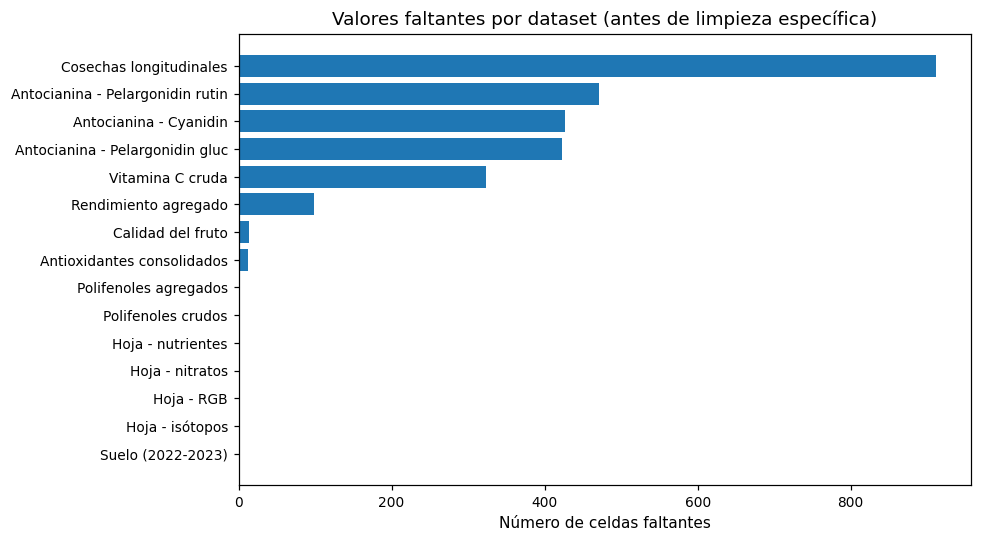

In [ ]:
# Resumen de faltantes por variable en las fuentes principales
missing_tables = []
for name, df in core_datasets.items():
    miss = df.isna().sum()
    miss = miss[miss > 0]
    for col, nmiss in miss.items():
        missing_tables.append({
            'Dataset': name, 'Variable': col,
            'Faltantes': int(nmiss), '%': round(100*nmiss/len(df), 1)
        })
missing_df = pd.DataFrame(missing_tables)
if len(missing_df):
    display(missing_df.sort_values(['Dataset', 'Faltantes'], ascending=[True, False]))
else:
    print('No se detectaron valores faltantes en las fuentes principales.')

# Visualización de faltantes agregados por dataset
miss_by_ds = profile.set_index('Dataset')['Celdas faltantes'].sort_values()
plt.figure(figsize=(9, 5))
plt.barh(miss_by_ds.index, miss_by_ds.values)
plt.xlabel('Número de celdas faltantes')
plt.title('Valores faltantes por dataset (antes de limpieza específica)')
plt.tight_layout()
plt.show()

In [ ]:
# Auditoría de réplicas técnicas: evita tratar mediciones repetidas como observaciones independientes.
poly_tmp = poly_raw.copy()
poly_tmp['Treatment'] = poly_tmp['Treatment'].astype(str).str.strip()
poly_tmp['cultivar'] = poly_tmp['cultivar'].astype(str).str.strip()
poly_tmp['Replicate'] = poly_tmp['Replicate'].astype(str).str.strip()

replicate_audit = []
replicate_audit.append({
    'Fuente': 'Polifenoles crudos',
    'Unidades experimentales': poly_tmp.groupby(['cultivar','Treatment','Replicate']).ngroups,
    'Mediciones por unidad (moda)': int(poly_tmp.groupby(['cultivar','Treatment','Replicate']).size().mode().iloc[0]),
})

for label, d in [('Cyanidin', antho_cyan_raw), ('Pelargonidin gluc', antho_pgluc_raw), ('Pelargonidin rutin', antho_prut_raw)]:
    x = d[d['Cv'].notna()].copy()
    counts = x.groupby(['Cv','Treat']).size()
    replicate_audit.append({
        'Fuente': label,
        'Unidades experimentales': counts.size,
        'Mediciones por unidad (moda)': int(counts.mode().iloc[0]),
    })

v = vitc_raw.copy()
counts = v.groupby(['CV','Sample ID']).size()
replicate_audit.append({
    'Fuente': 'Vitamina C cruda',
    'Unidades experimentales': counts.size,
    'Mediciones por unidad (moda)': int(counts.mode().iloc[0]),
})

display(pd.DataFrame(replicate_audit))

,Fuente,Unidades experimentales,Mediciones por unidad (moda)
0,Polifenoles crudos,32,2
1,Cyanidin,32,3
2,Pelargonidin gluc,32,3
3,Pelargonidin rutin,32,3
4,Vitamina C cruda,32,2


**Interpretación:** los archivos crudos de polifenoles, antocianinas y vitamina C contienen mediciones técnicas repetidas. Para análisis entre tratamientos y cultivares se trabaja con las versiones agregadas, evitando pseudorreplicación. Las fuentes crudas permanecen útiles para revisar dispersión analítica y trazabilidad.


## 4. Análisis univariante

Se emplean histogramas para observar forma y sesgo de las distribuciones, boxplots para localizar observaciones extremas y barras para categorías. Las gráficas se generan por bloque temático para mantener legibilidad.


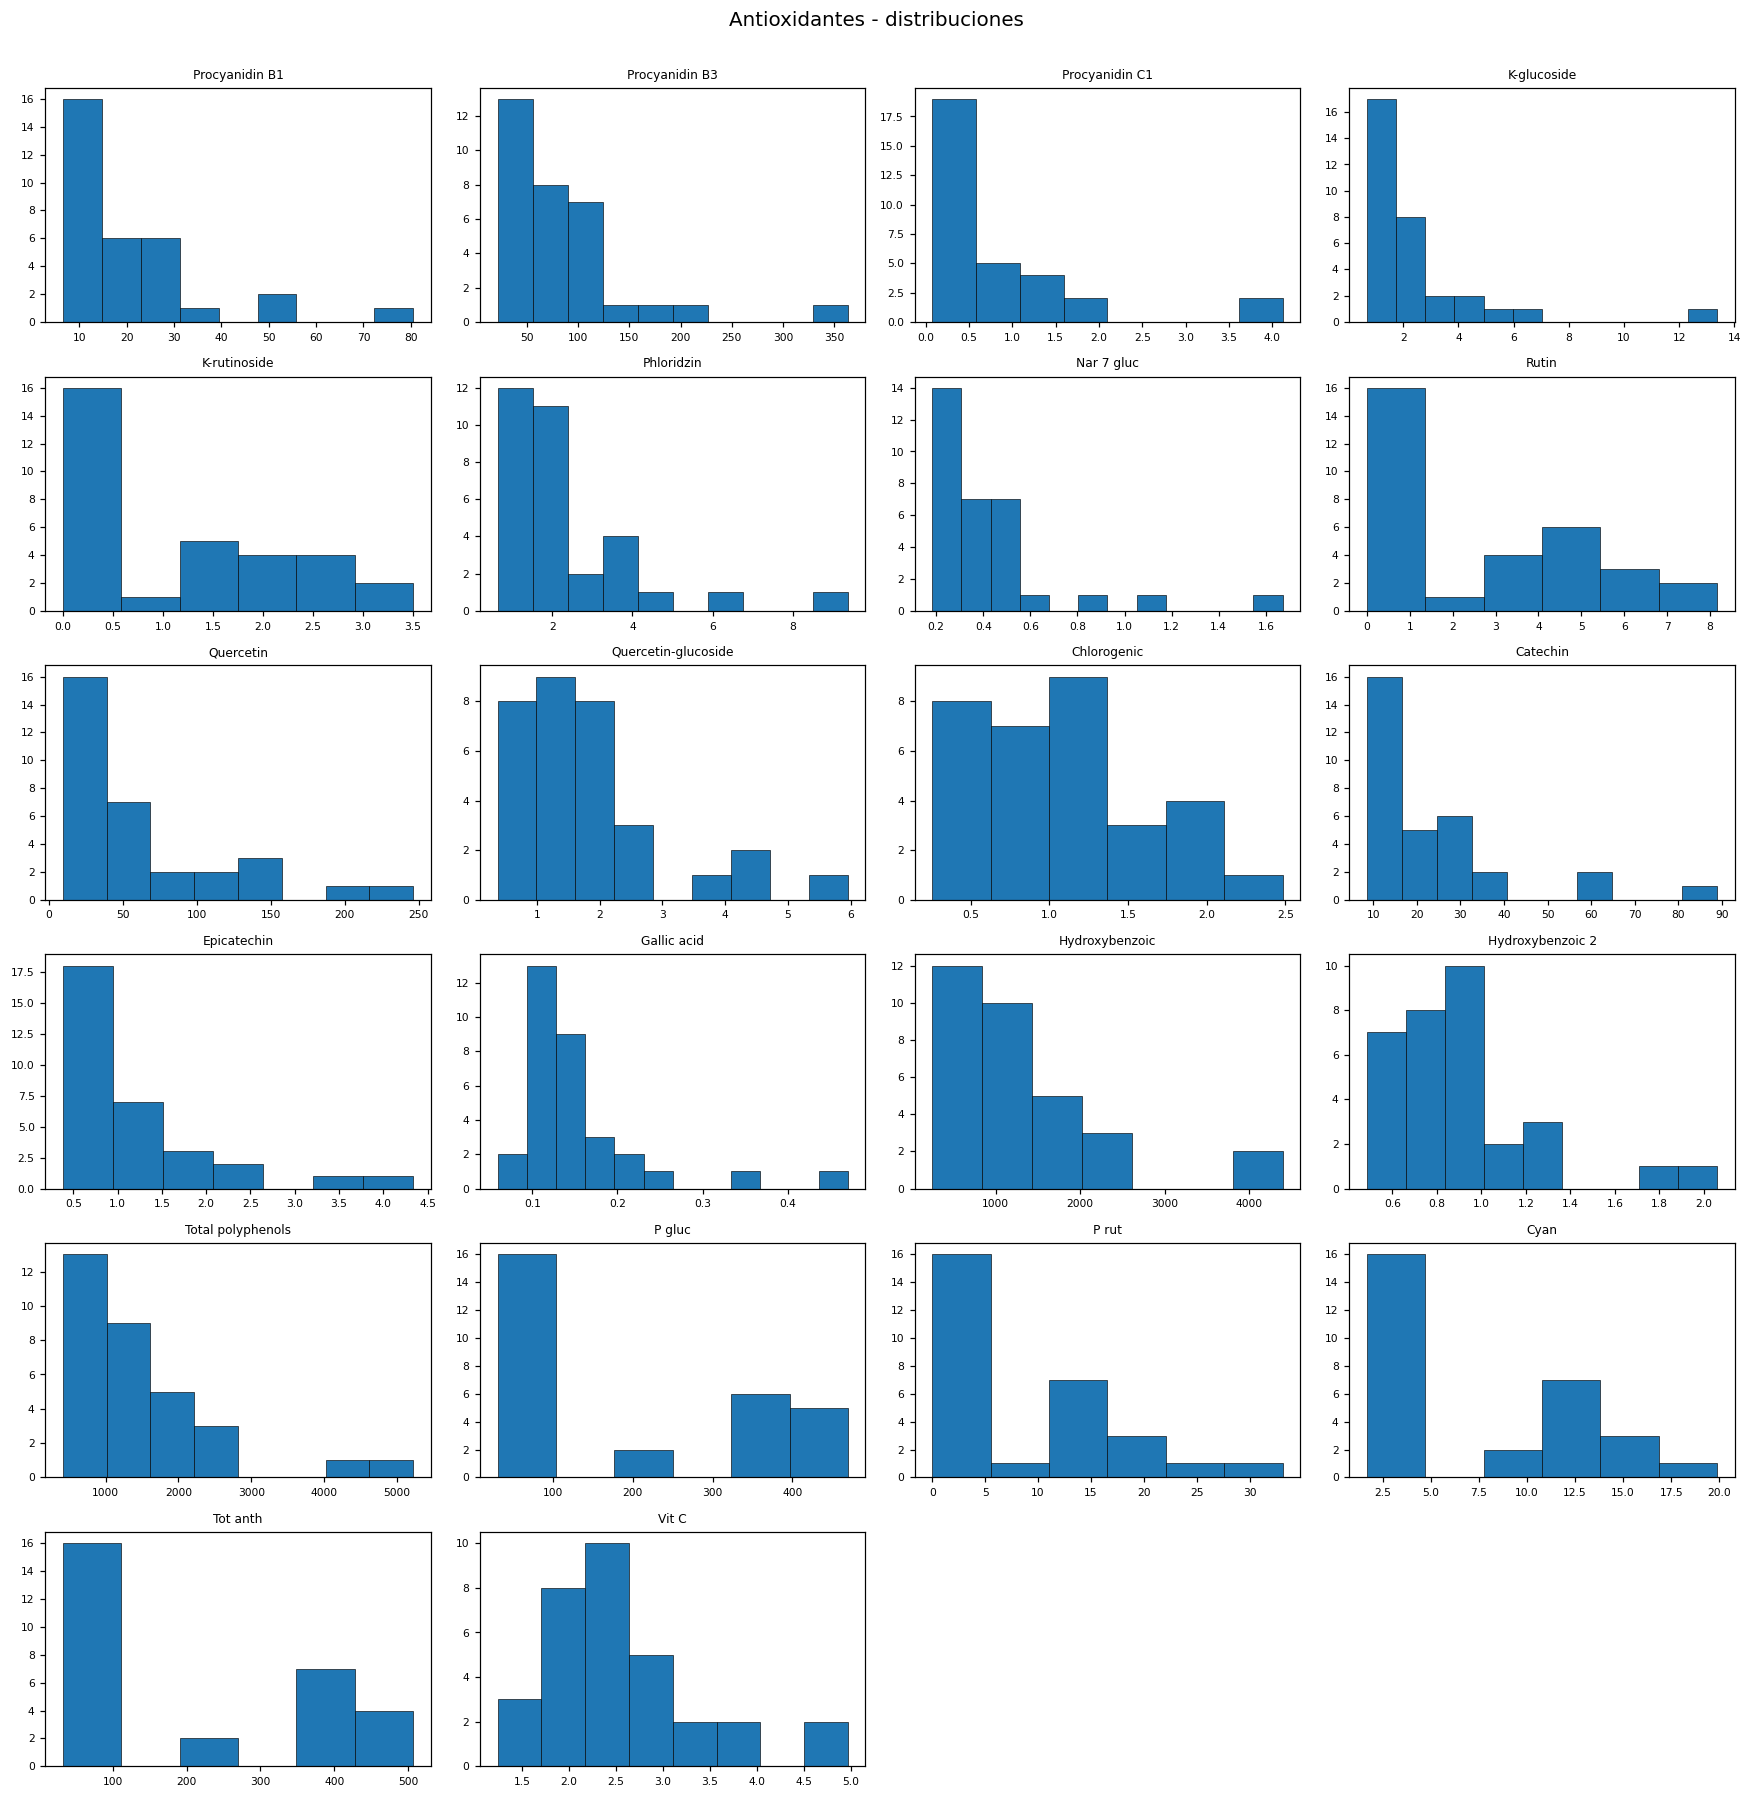

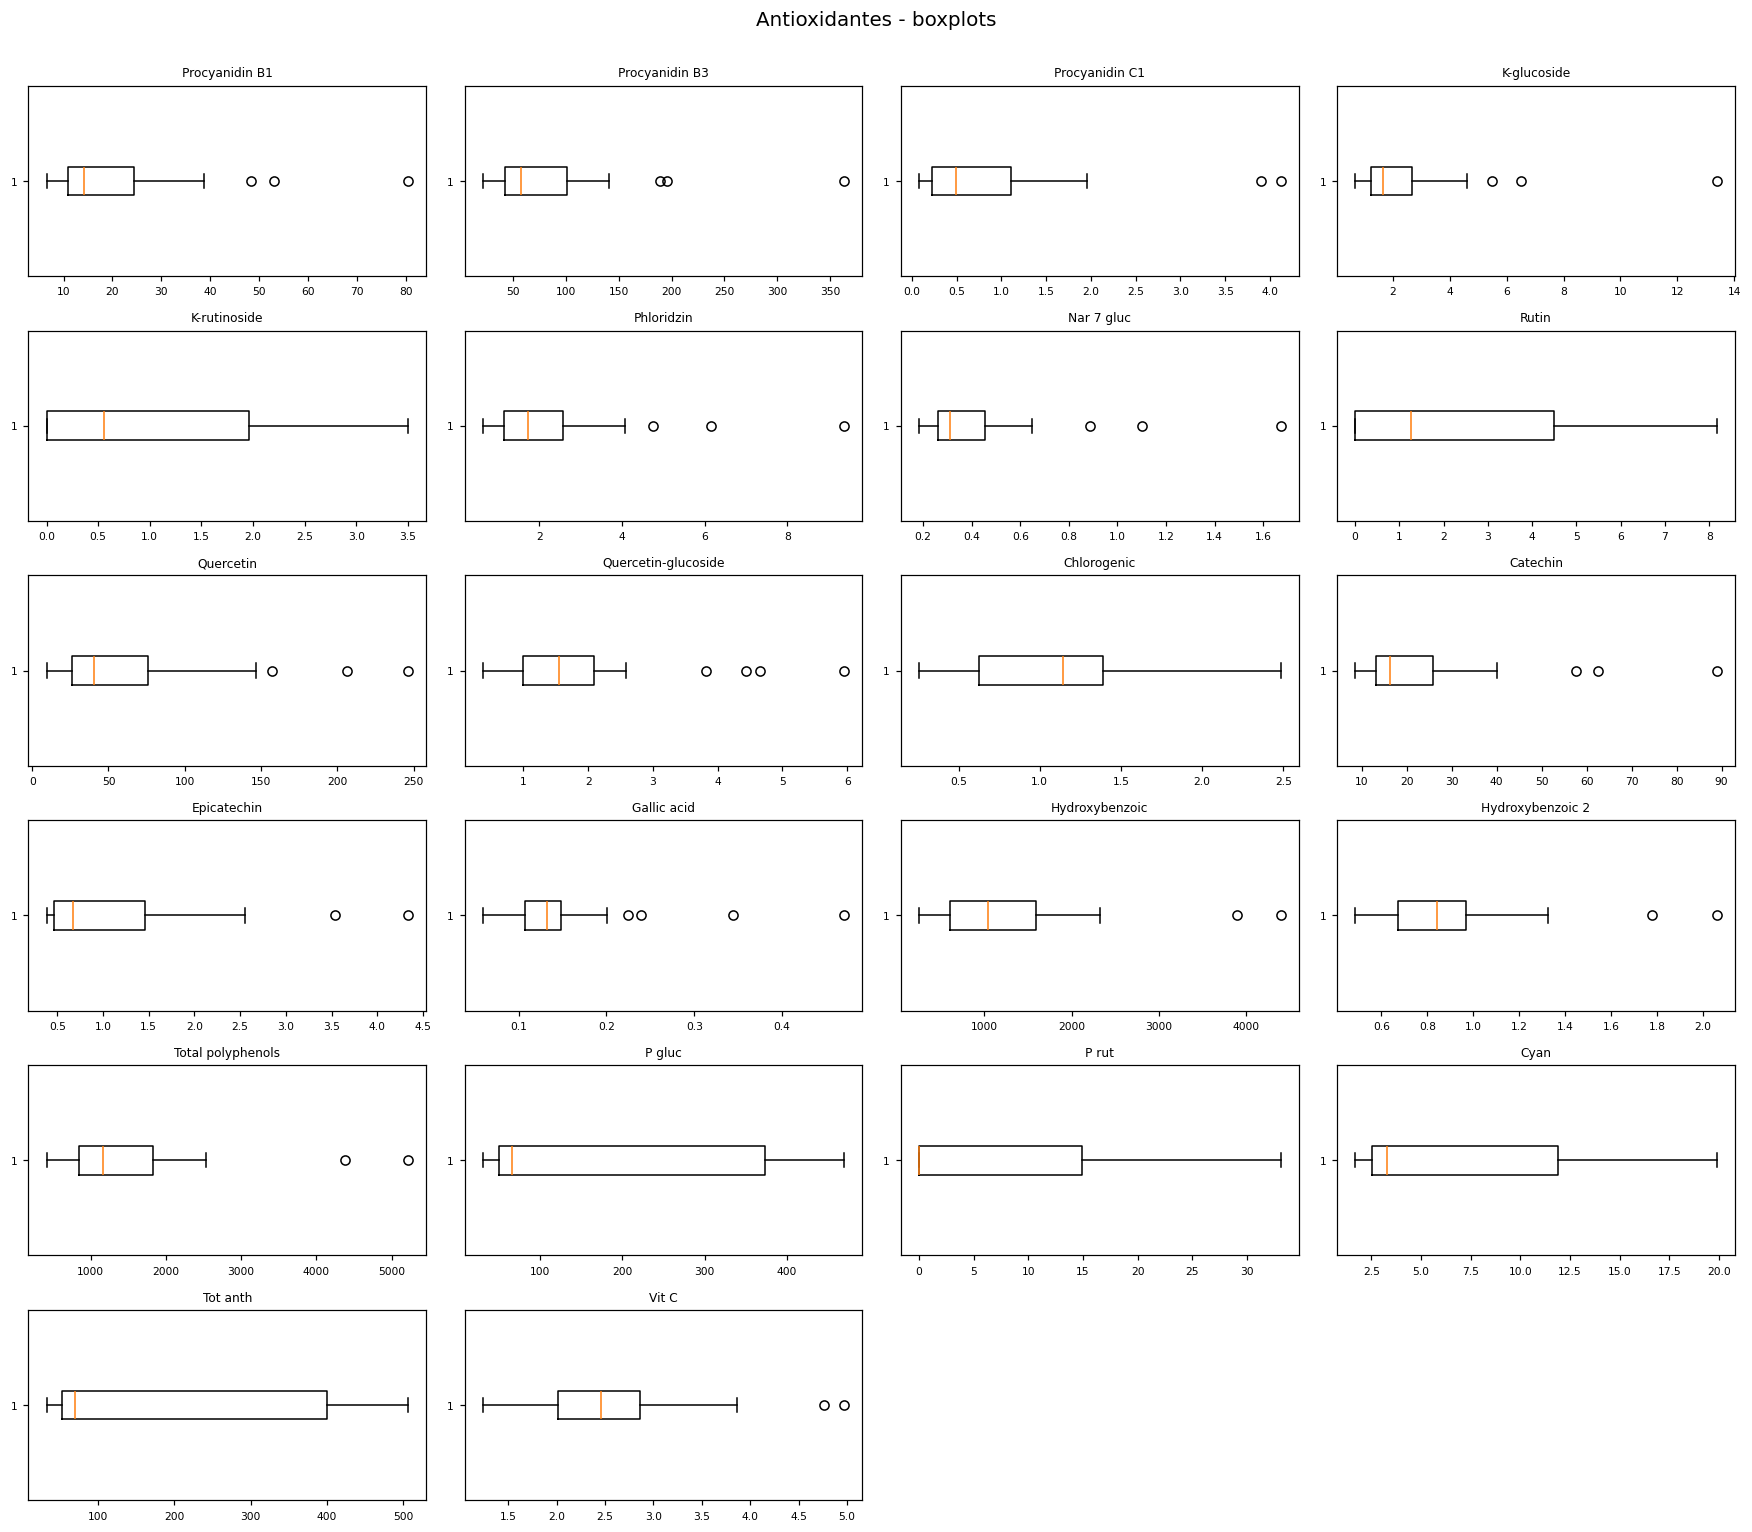

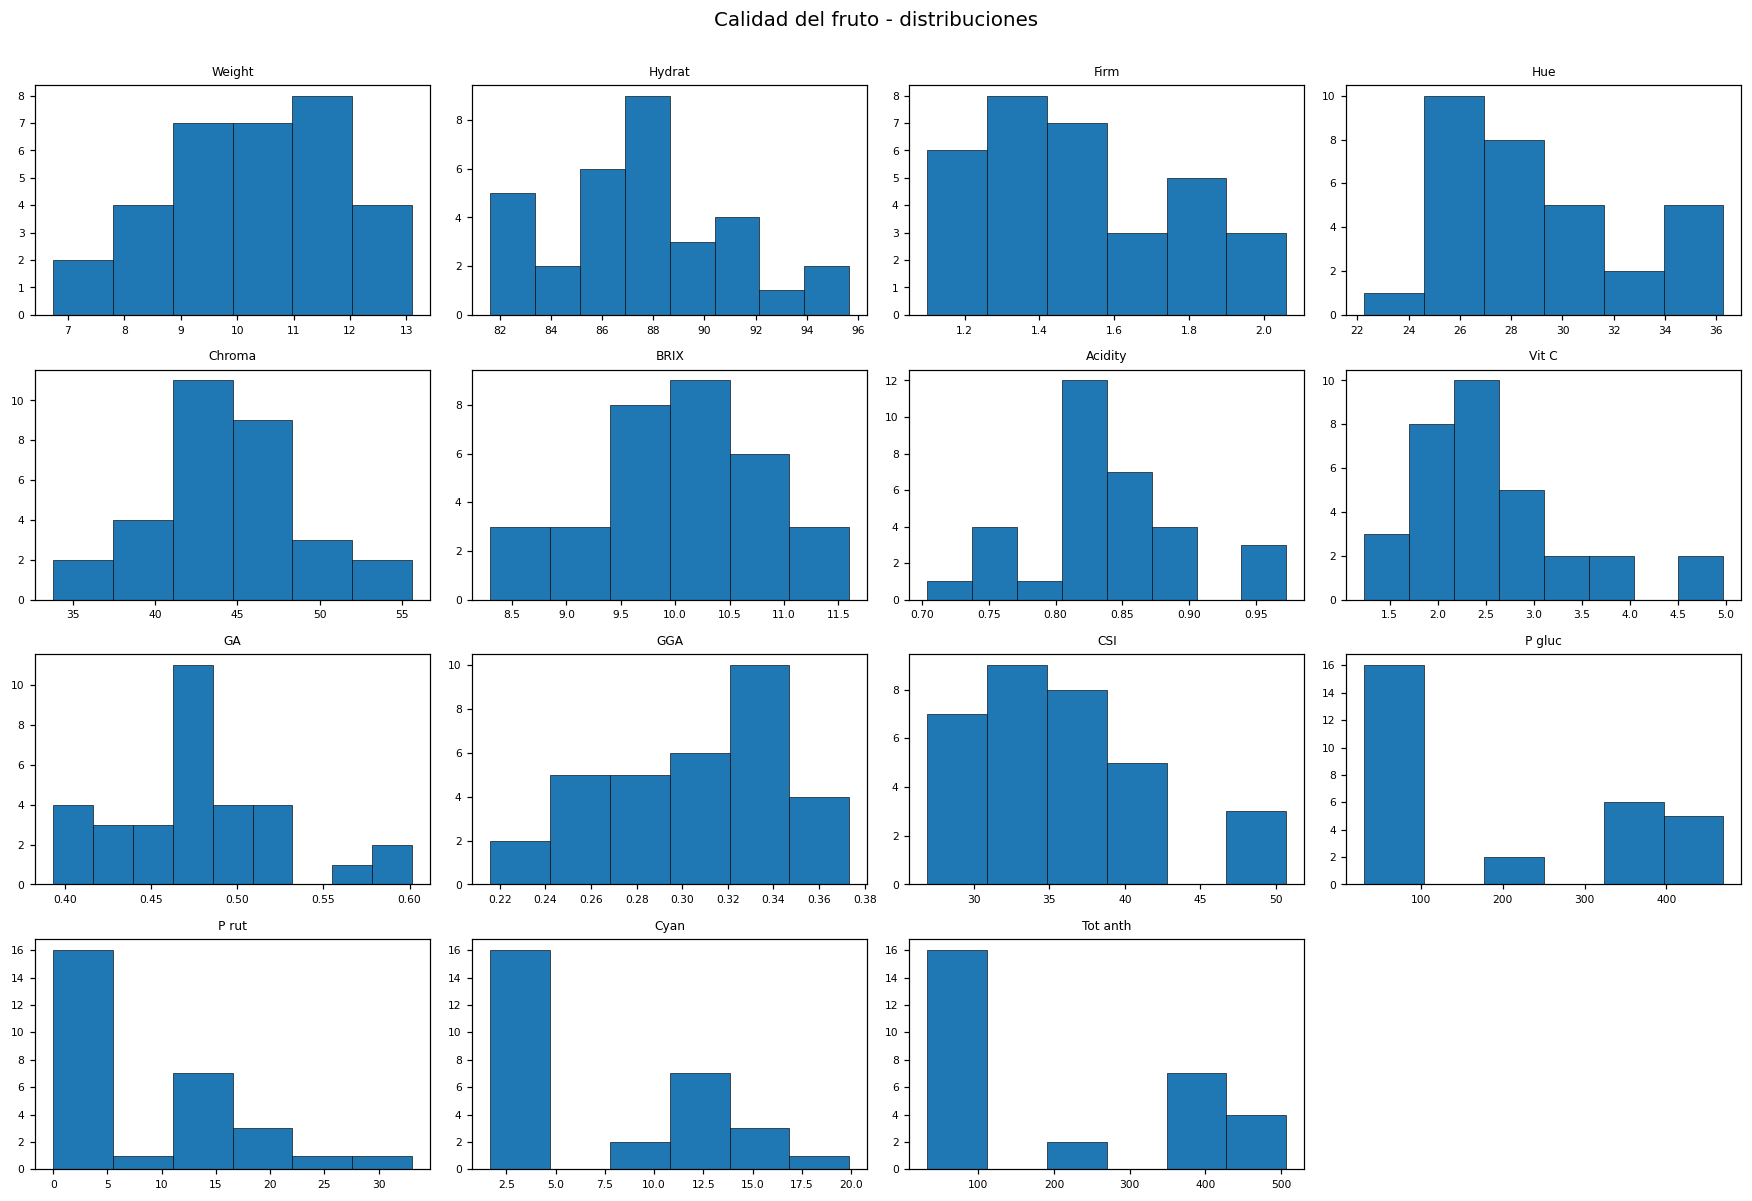

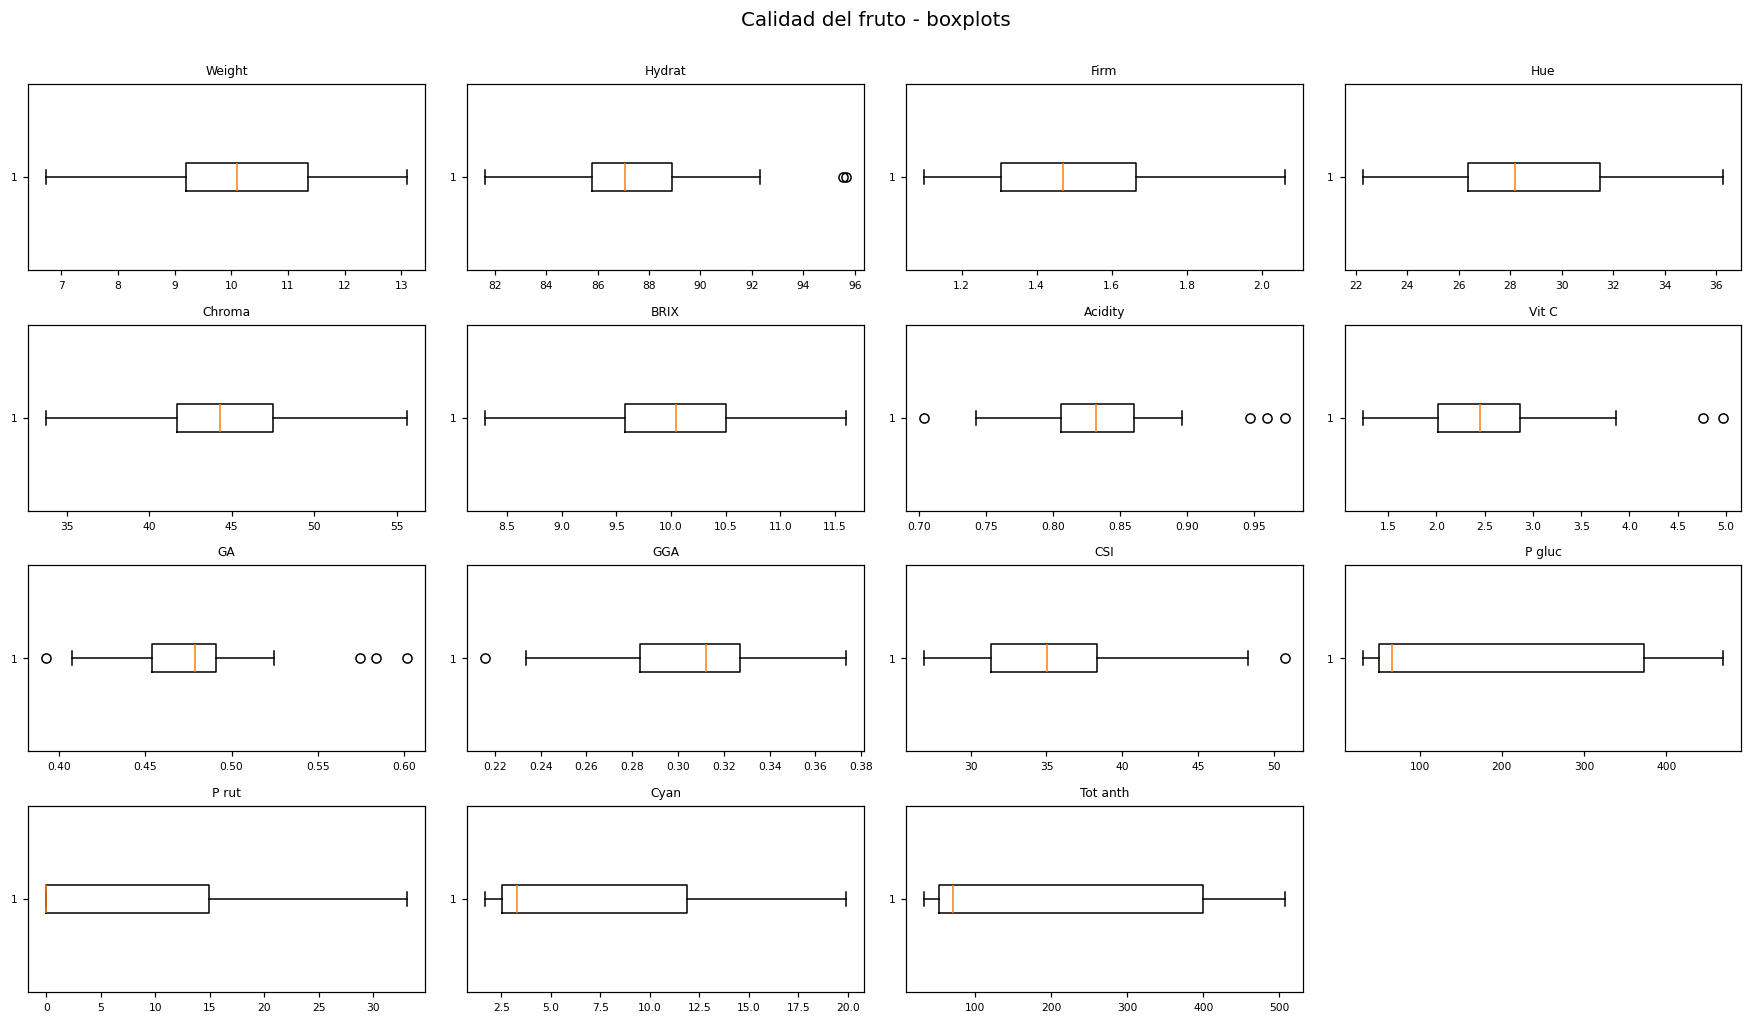

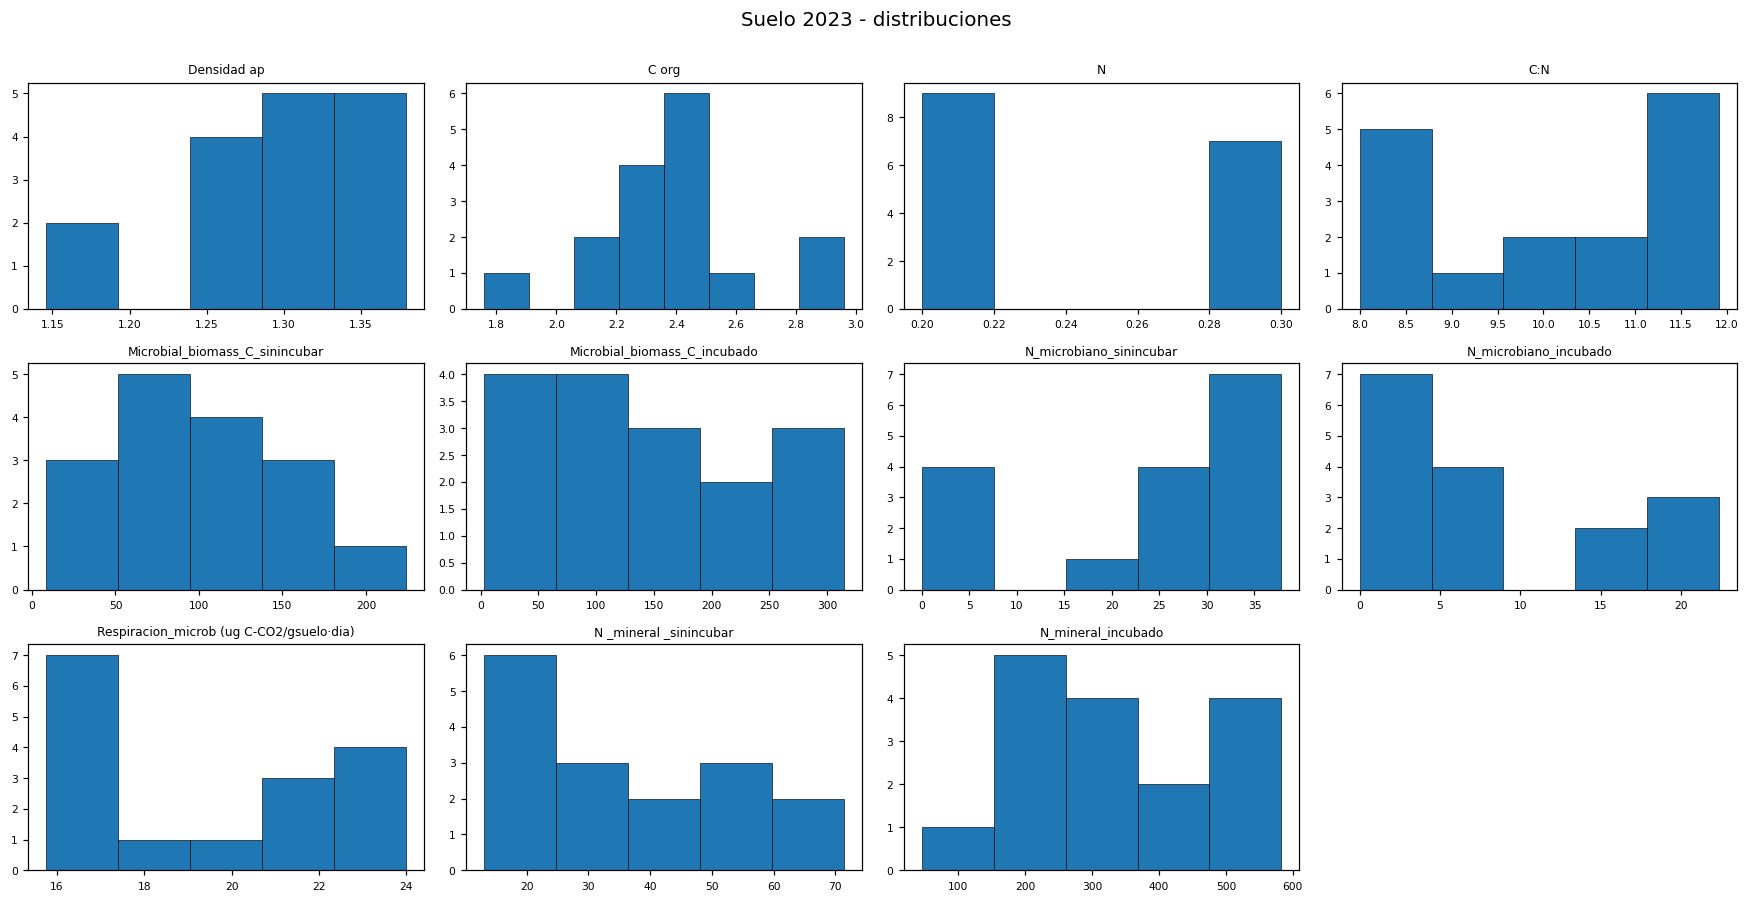

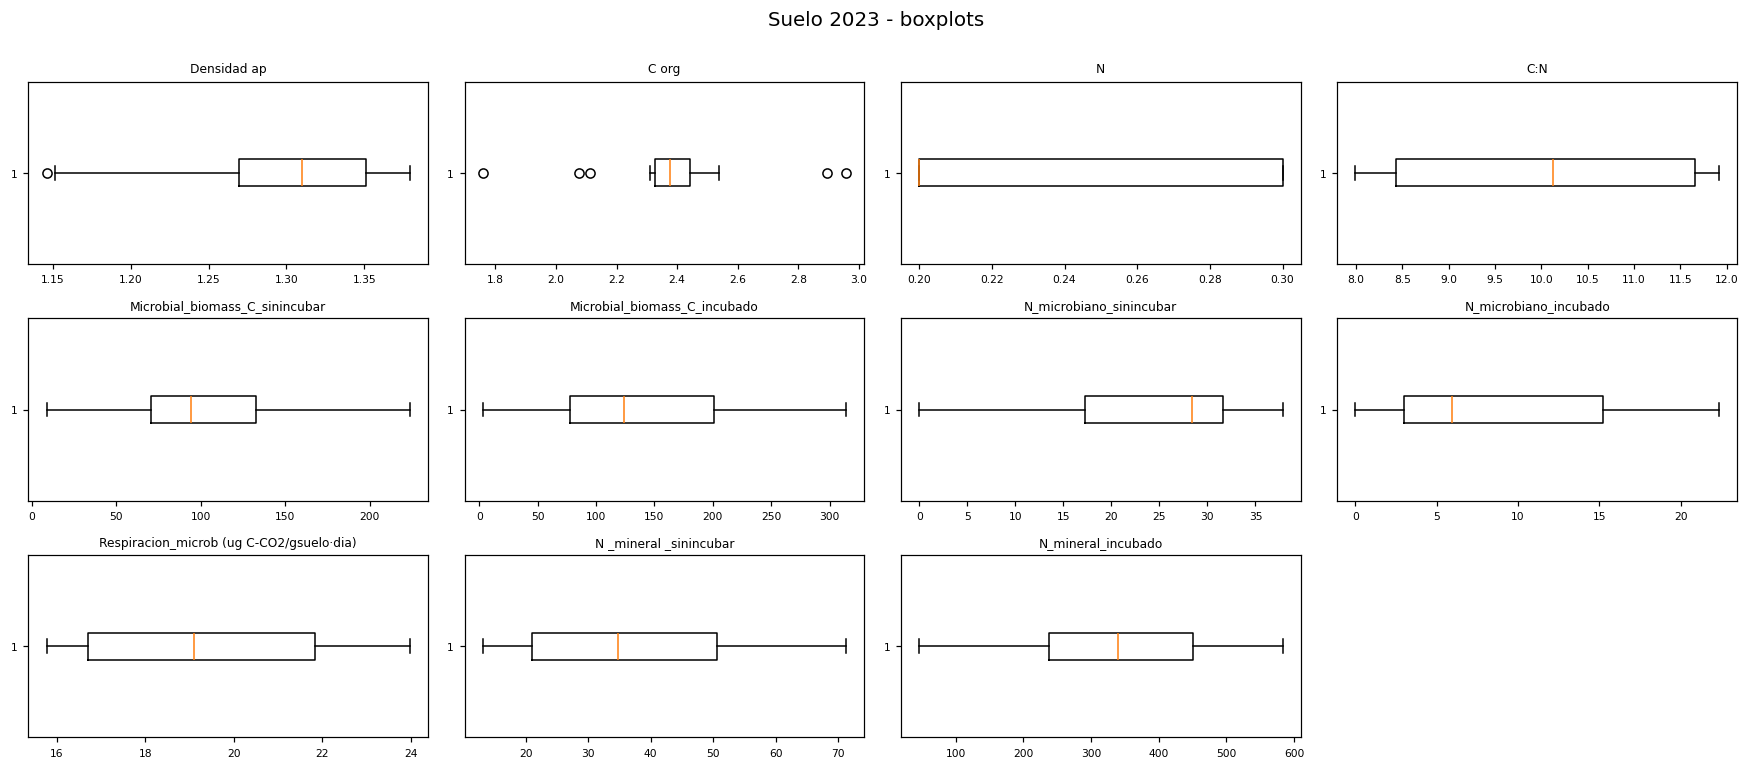

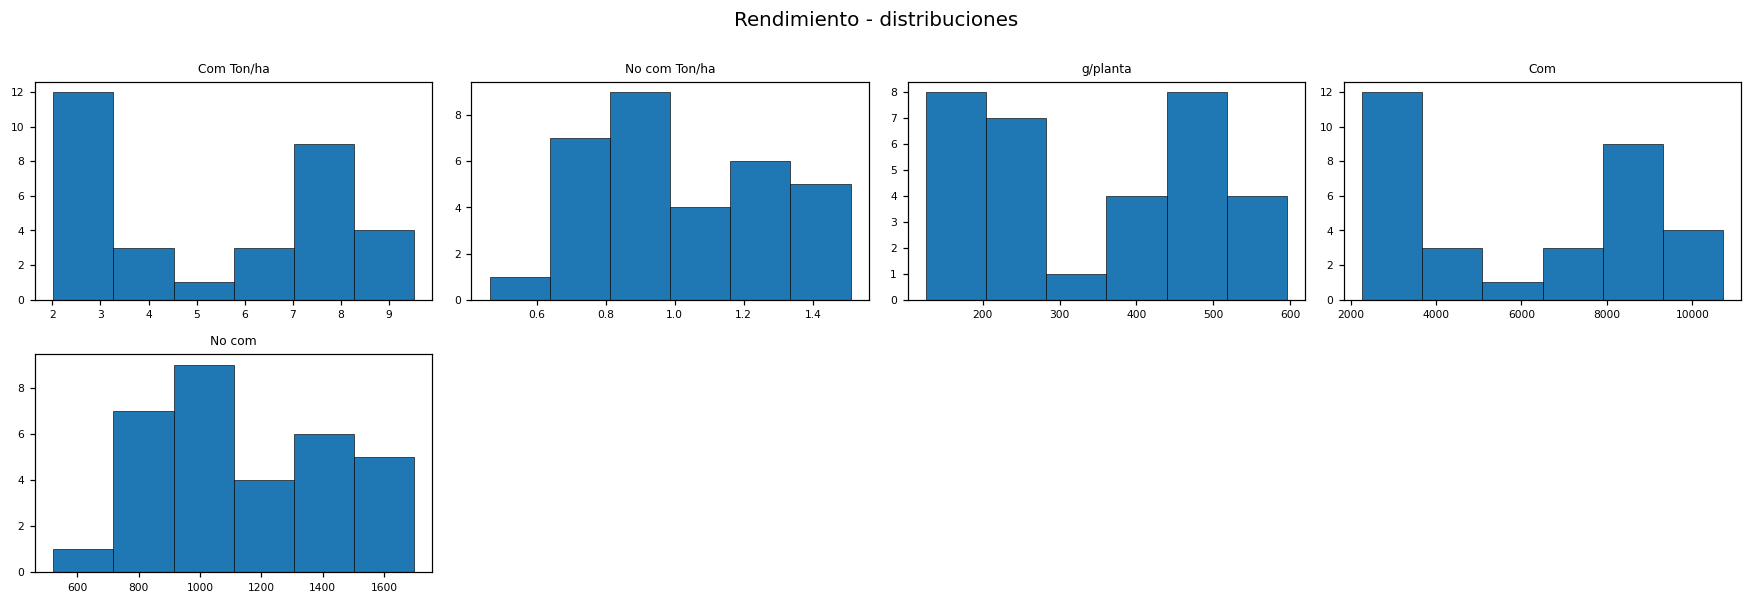

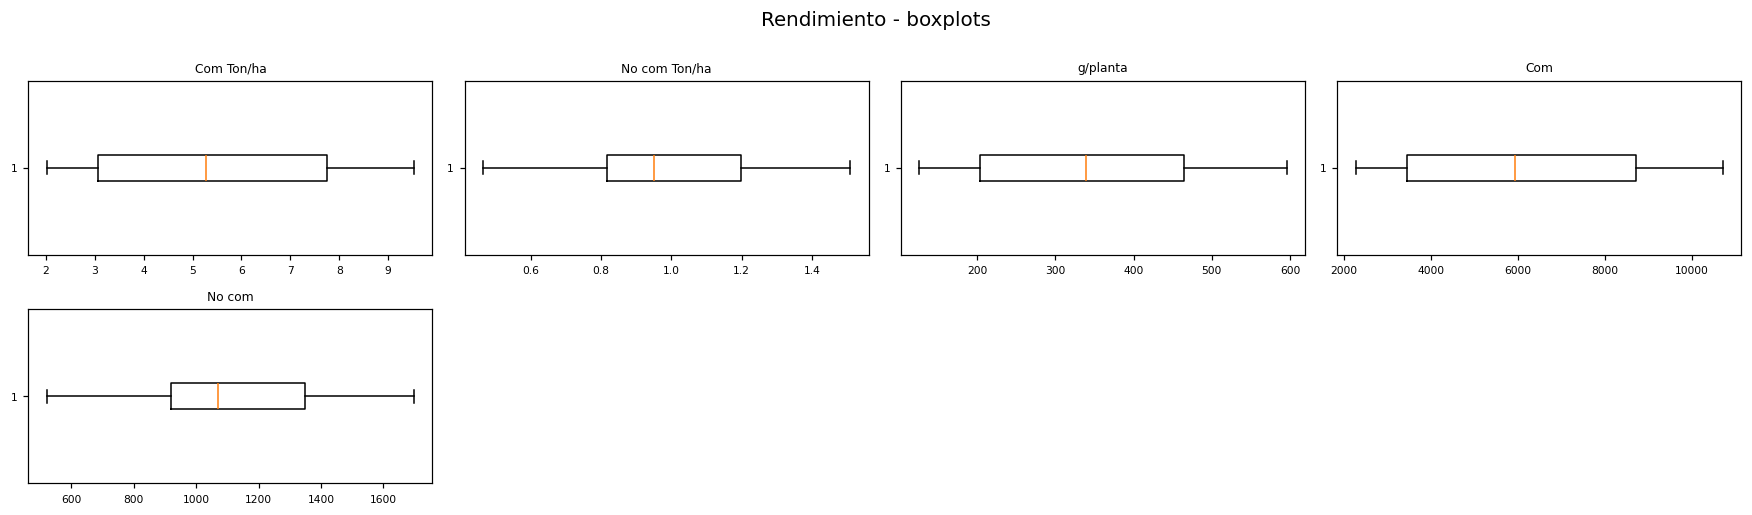

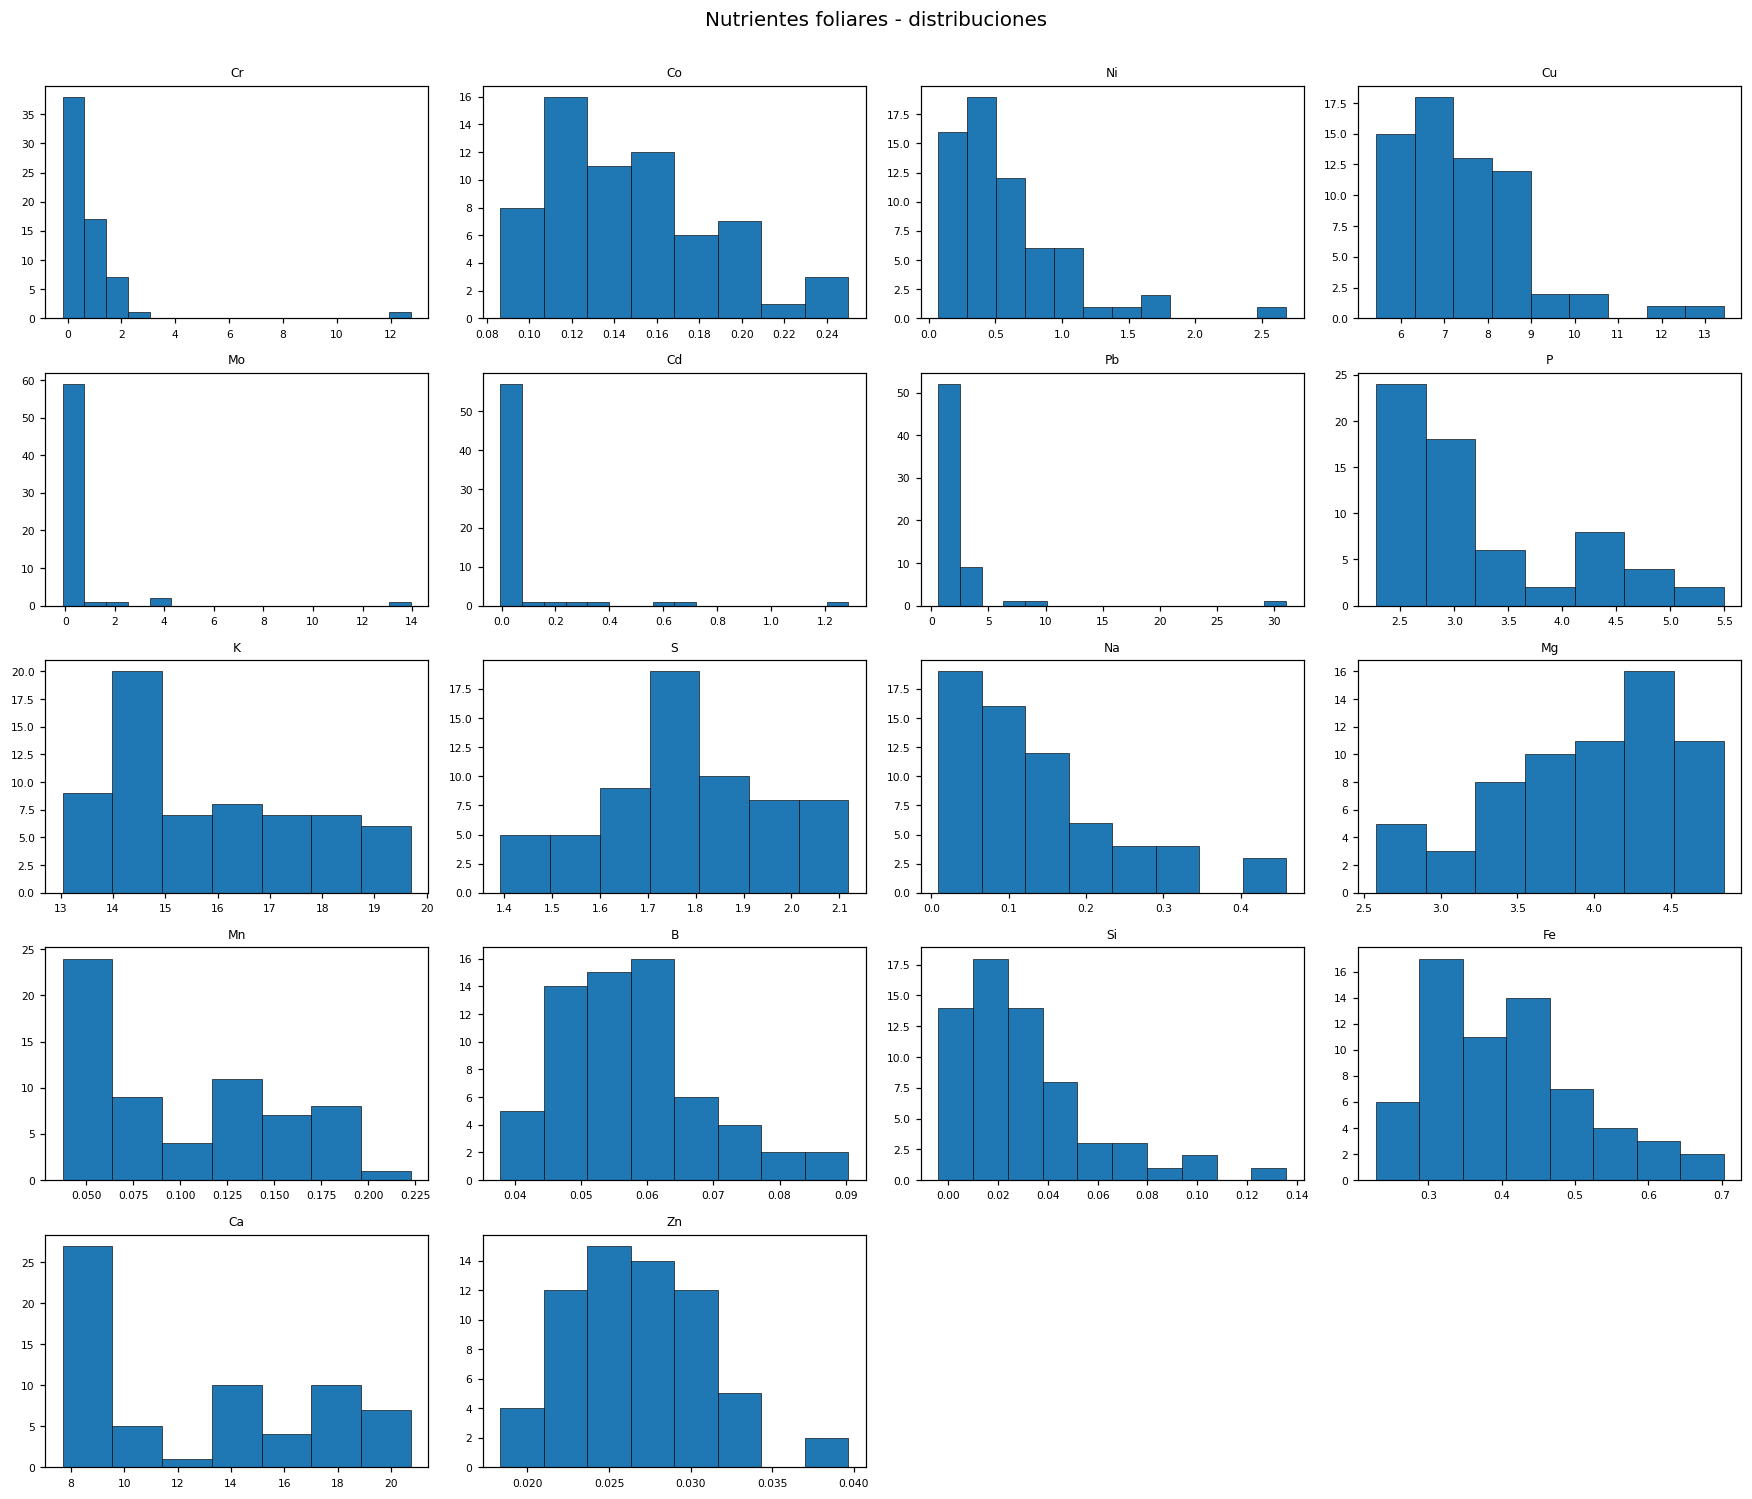

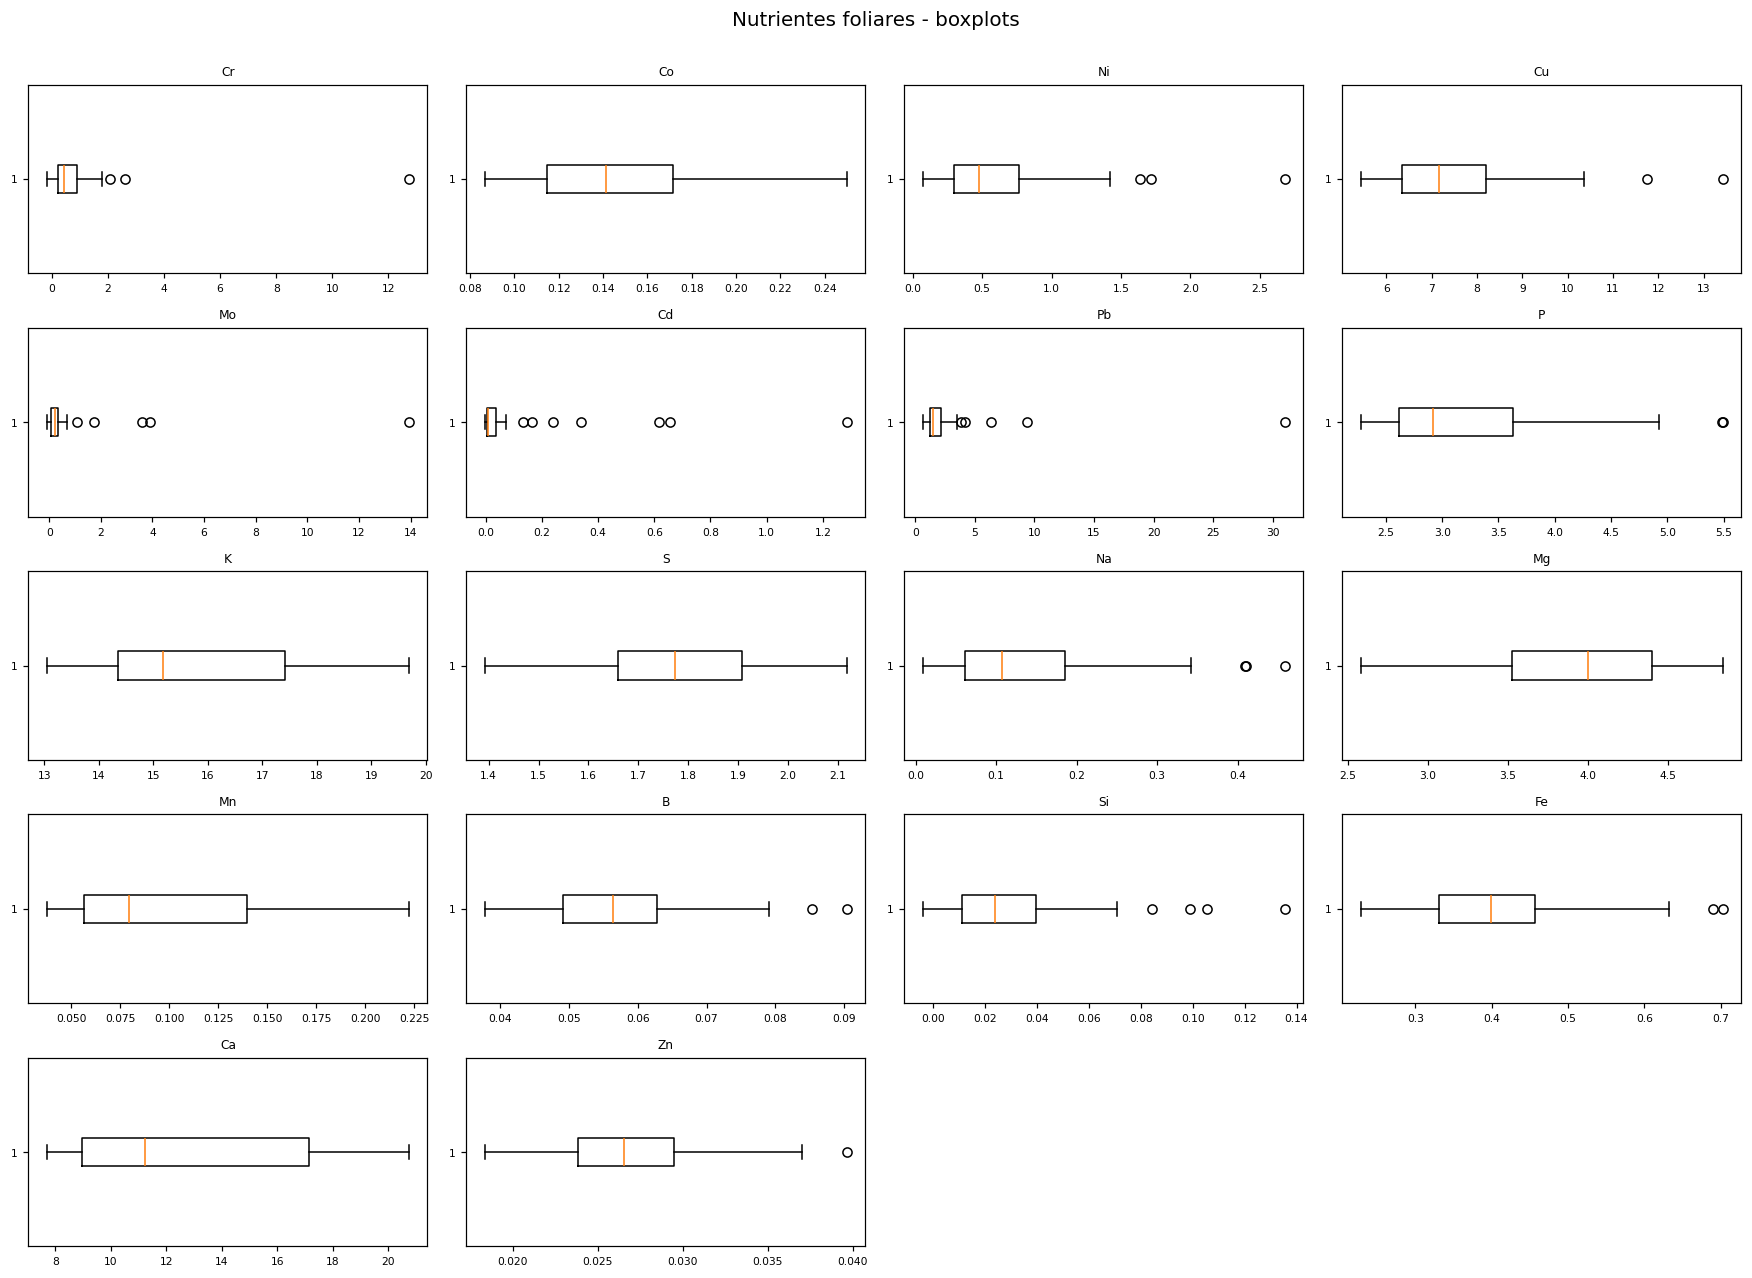

In [ ]:
def numeric_measure_columns(df, exclude_keywords=None):
    cols = list(df.select_dtypes(include=np.number).columns)
    exclude_keywords = exclude_keywords or []
    return [c for c in cols if not any(k.lower() in c.lower() for k in exclude_keywords)]


def plot_hist_grid(df, cols, title, ncols=4):
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 2.7*nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, cols):
        x = pd.to_numeric(df[c], errors='coerce').dropna()
        ax.hist(x, bins='auto', edgecolor='black', linewidth=0.4)
        ax.set_title(c, fontsize=8)
        ax.tick_params(labelsize=7)
    for ax in axes[len(cols):]:
        ax.axis('off')
    fig.suptitle(title, fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()


def plot_box_grid(df, cols, title, ncols=4):
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 2.3*nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, cols):
        x = pd.to_numeric(df[c], errors='coerce').dropna()
        ax.boxplot(x, vert=False)
        ax.set_title(c, fontsize=8)
        ax.tick_params(labelsize=7)
    for ax in axes[len(cols):]:
        ax.axis('off')
    fig.suptitle(title, fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()

# Selección de columnas de medición; se excluyen IDs y columnas de soporte.
antiox_num = numeric_measure_columns(antiox_raw)
fruit_num = [c for c in ['Weight','Hydrat','Firm','Hue','Chroma','BRIX','Acidity','Vit C','GA','GGA','CSI','P gluc','P rut','Cyan','Tot anth'] if c in fruit_raw]
soil_2023 = soil_raw[soil_raw['Year'].eq(2023)].copy()
soil_num = [c for c in soil_2023.select_dtypes(include=np.number).columns if c not in ['Year','Plot']]
yield_num = [c for c in ['Com Ton/ha','No com Ton/ha','g/planta','Com','No com'] if c in yield_raw]
leaf_nut_num = list(leaf_nutrients_raw.select_dtypes(include=np.number).columns)
leaf_nut_num = [c for c in leaf_nut_num if c not in ['Sample','Parcel/Plot']]

plot_hist_grid(antiox_raw, antiox_num, 'Antioxidantes - distribuciones')
plot_box_grid(antiox_raw, antiox_num, 'Antioxidantes - boxplots')

plot_hist_grid(fruit_raw, fruit_num, 'Calidad del fruto - distribuciones')
plot_box_grid(fruit_raw, fruit_num, 'Calidad del fruto - boxplots')

plot_hist_grid(soil_2023, soil_num, 'Suelo 2023 - distribuciones')
plot_box_grid(soil_2023, soil_num, 'Suelo 2023 - boxplots')

plot_hist_grid(yield_raw, yield_num, 'Rendimiento - distribuciones')
plot_box_grid(yield_raw, yield_num, 'Rendimiento - boxplots')

plot_hist_grid(leaf_nutrients_raw, leaf_nut_num, 'Nutrientes foliares - distribuciones')
plot_box_grid(leaf_nutrients_raw, leaf_nut_num, 'Nutrientes foliares - boxplots')

In [ ]:
# Sesgo: se identifican variables candidatas a transformación no lineal.
skew_rows = []
for name, df in core_datasets.items():
    num = df.select_dtypes(include=np.number)
    for col, value in num.skew(numeric_only=True).items():
        if pd.notna(value):
            skew_rows.append({'Dataset': name, 'Variable': col, 'Skewness': value, 'Requiere revisión': abs(value) > 1})

skew_df = pd.DataFrame(skew_rows).sort_values('Skewness', key=lambda s: s.abs(), ascending=False)
display(skew_df.head(40).round(3))
print(f"Variables con |skewness| > 1: {int(skew_df['Requiere revisión'].sum())}")

,Dataset,Variable,Skewness,Requiere revisión
81,Hoja - nitratos,Vol extract (L),8.000,True
95,Hoja - nutrientes,Pb,6.703,True
93,Hoja - nutrientes,Mo,6.597,True
89,Hoja - nutrientes,Cr,6.580,True
94,Hoja - nutrientes,Cd,4.759,True
3,Antioxidantes consolidados,K-glucoside,3.208,True
6,Antioxidantes consolidados,Nar 7 gluc,2.901,True
1,Antioxidantes consolidados,Procyanidin B3,2.747,True
13,Antioxidantes consolidados,Gallic acid,2.722,True
5,Antioxidantes consolidados,Phloridzin,2.378,True


Variables con |skewness| > 1: 37


## 5. Valores atípicos

Se usa la regla de 1.5×IQR como **bandera de revisión**, no como criterio automático de eliminación. En un experimento agronómico, un valor extremo puede representar una respuesta biológica real. Para el análisis multivariante se reduce su influencia mediante transformación Yeo-Johnson y escalamiento robusto.


In [ ]:
def iqr_outlier_summary(df, dataset_name):
    rows = []
    for c in df.select_dtypes(include=np.number).columns:
        x = df[c].dropna()
        if len(x) < 4:
            continue
        q1, q3 = x.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = (q1 - 1.5*iqr, q3 + 1.5*iqr) if iqr > 0 else (q1, q3)
        n = int(((x < lo) | (x > hi)).sum())
        if n:
            rows.append({'Dataset': dataset_name, 'Variable': c, 'Atípicos IQR': n, 'Límite inf.': lo, 'Límite sup.': hi})
    return rows

outlier_rows = []
for name, df in core_datasets.items():
    outlier_rows.extend(iqr_outlier_summary(df, name))
outlier_df = pd.DataFrame(outlier_rows)
if len(outlier_df):
    display(outlier_df.sort_values('Atípicos IQR', ascending=False).head(50).round(3))
else:
    print('No se detectaron atípicos mediante la regla IQR.')

,Dataset,Variable,Atípicos IQR,Límite inf.,Límite sup.
22,Cosechas longitudinales,Com,46,-383.875,909.125
25,Cosechas longitudinales,com/plant,45,-20.899,50.531
24,Cosechas longitudinales,Plants,42,15.500,19.500
23,Cosechas longitudinales,No com,30,-89.875,187.125
26,Cosechas longitudinales,no com/plant,29,-5.276,10.894
27,Cosechas longitudinales,Commercial (g/plant),19,-38.389,100.661
28,Cosechas longitudinales,Non-commercial (g/plant),9,-7.884,20.246
41,Hoja - nutrientes,Cd,7,-0.046,0.086
30,Suelo (2022-2023),Microbial_biomass_C_incubado,6,54.489,211.705
42,Hoja - nutrientes,Pb,5,-0.184,3.537


## 6. Análisis bivariante por categorías

Se exploran resultados de interés por **cultivar** y **tratamiento**. Esta comparación es descriptiva; no sustituye pruebas inferenciales ni permite concluir causalidad por sí sola.


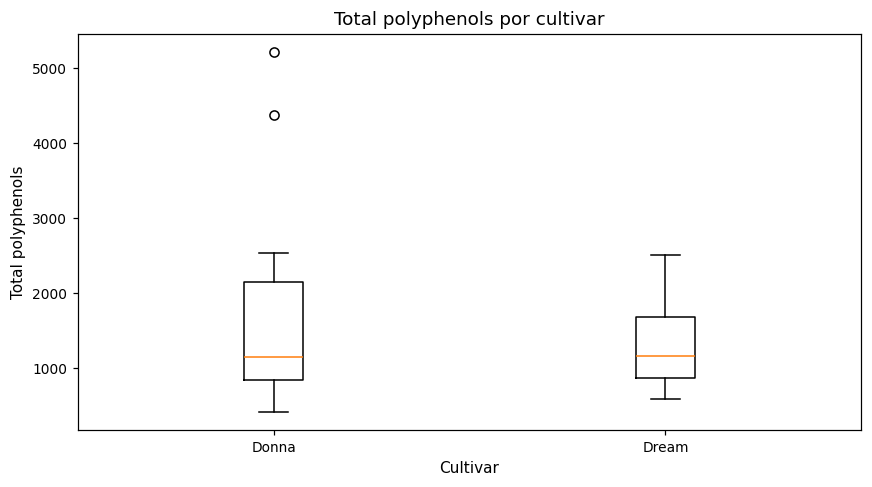

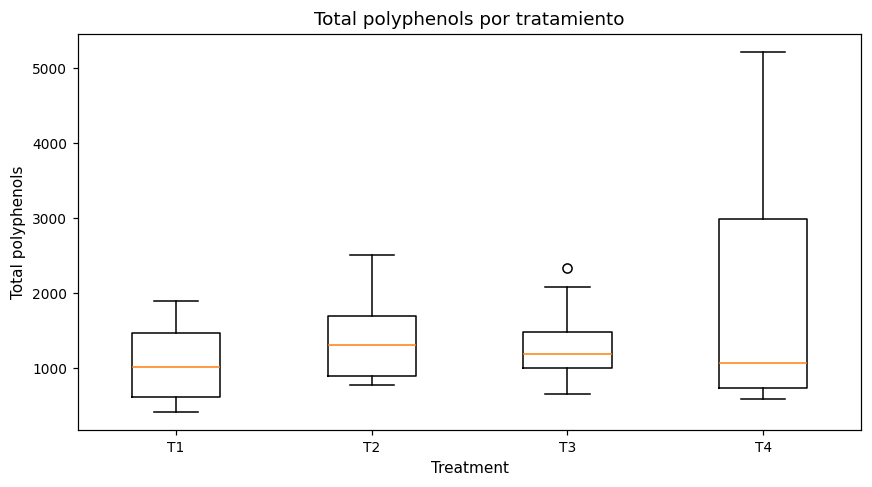

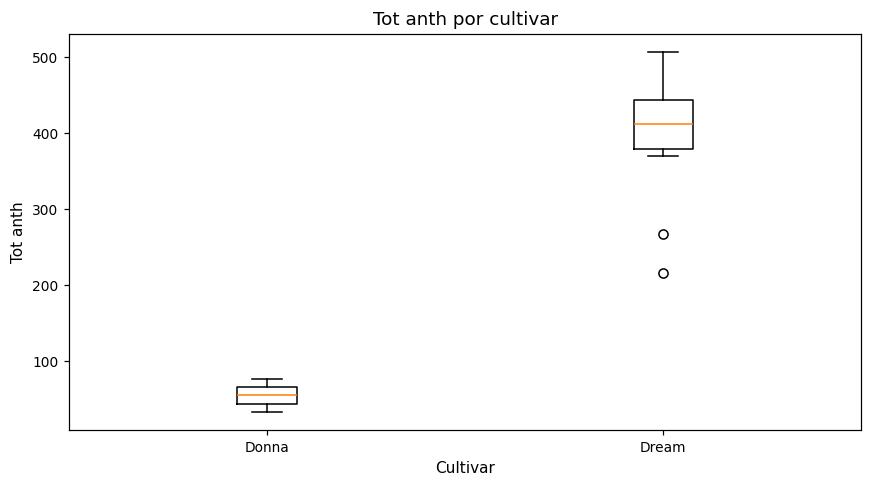

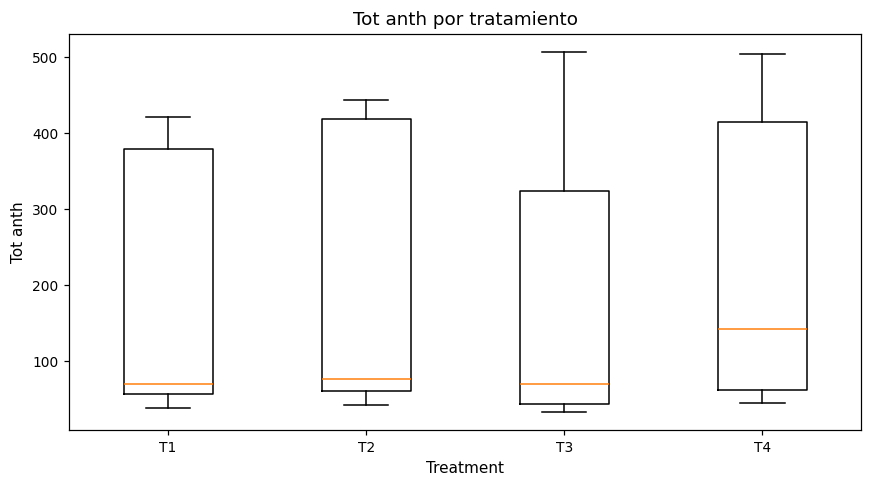

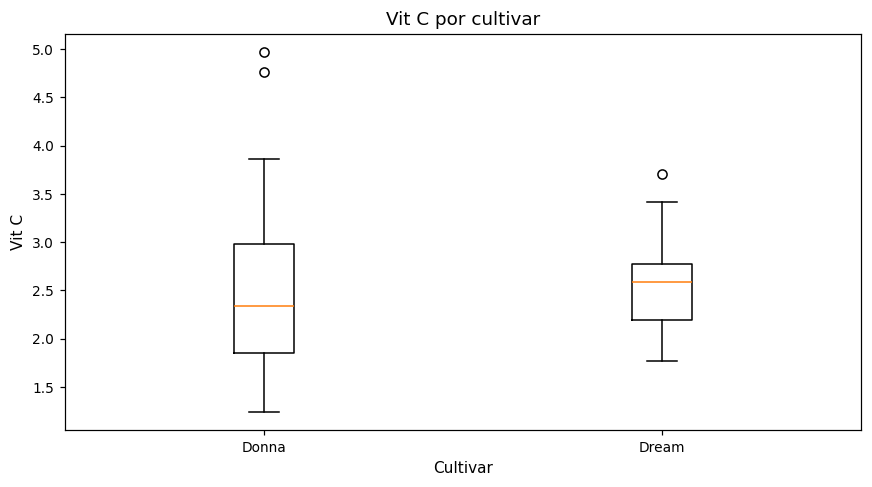

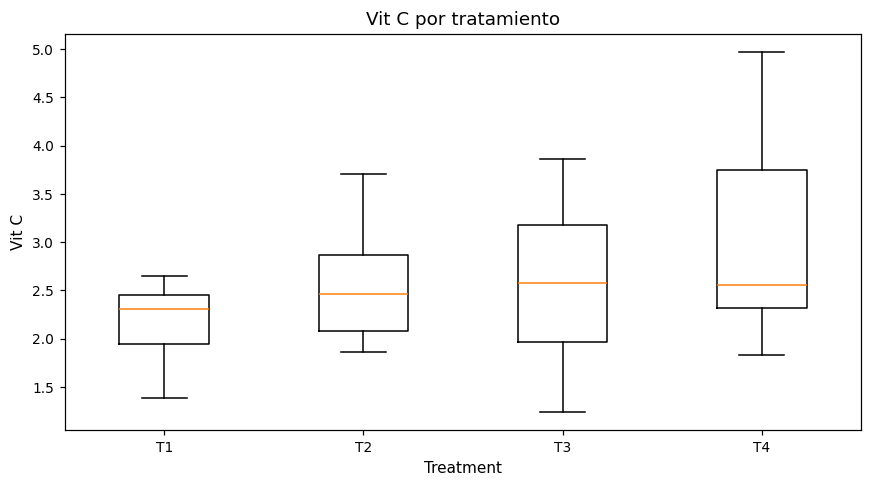

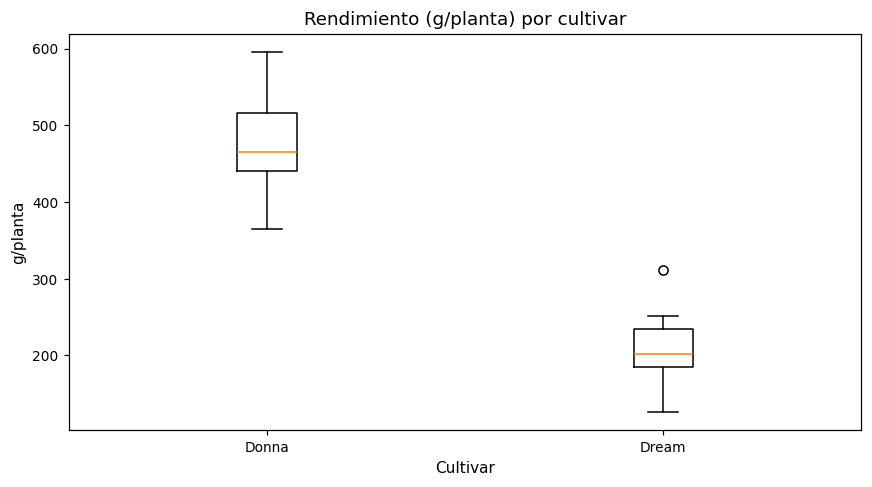

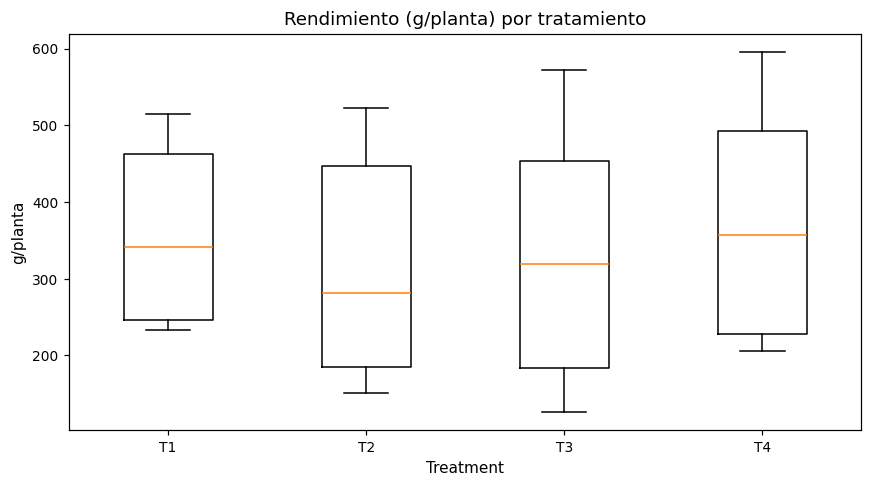

In [ ]:
# Estandarización temporal de categorías para gráficos bivariados.
antiox_plot = antiox_raw.copy()
antiox_plot['Cultivar'] = standardize_cultivar(antiox_plot['cultivar'])
antiox_plot['Treatment'] = standardize_treatment(antiox_plot['Treatment'])

yield_plot = yield_raw.copy()
yield_plot['Cultivar'] = standardize_cultivar(yield_plot['Cv'])
yield_plot['Treatment'] = standardize_treatment(yield_plot['Treatment'])


def boxplot_by_group(df, y, group, title):
    categories = [x for x in sorted(df[group].dropna().unique())]
    data = [df.loc[df[group].eq(g), y].dropna().values for g in categories]
    plt.figure(figsize=(8, 4.5))
    plt.boxplot(data, labels=categories)
    plt.ylabel(y)
    plt.xlabel(group)
    plt.title(title)
    plt.tight_layout()
    plt.show()

for outcome in ['Total polyphenols', 'Tot anth', 'Vit C']:
    boxplot_by_group(antiox_plot, outcome, 'Cultivar', f'{outcome} por cultivar')
    boxplot_by_group(antiox_plot, outcome, 'Treatment', f'{outcome} por tratamiento')

boxplot_by_group(yield_plot, 'g/planta', 'Cultivar', 'Rendimiento (g/planta) por cultivar')
boxplot_by_group(yield_plot, 'g/planta', 'Treatment', 'Rendimiento (g/planta) por tratamiento')

## 7. Tendencias temporales

El proyecto sí contiene dimensión temporal: cosechas sucesivas, mediciones foliares en marzo/mayo y RGB foliar también en diciembre. La columna `Day` de cosechas combina fechas de Excel con textos en catalán (`maig`, `juny`), por lo que se normaliza antes de analizarla.


Fechas originales únicas: 19
Fechas normalizadas válidas: 19


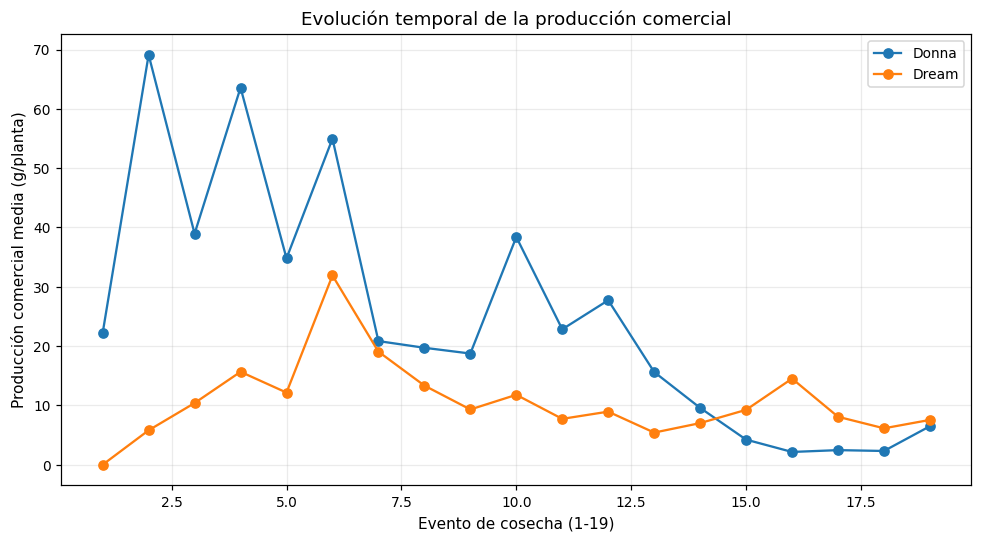

In [ ]:
# Normalización de fecha de cosecha
MONTH_MAP = {'maig': 5, 'juny': 6}

def parse_harvest_day(v, year=2023):
    if pd.isna(v):
        return pd.NaT
    if isinstance(v, pd.Timestamp):
        return v
    if hasattr(v, 'year') and hasattr(v, 'month') and hasattr(v, 'day'):
        try:
            return pd.Timestamp(v)
        except Exception:
            pass
    txt = str(v).strip().lower()
    m = re.match(r'^(\d{1,2})\s+(maig|juny)$', txt)
    if m:
        return pd.Timestamp(year=year, month=MONTH_MAP[m.group(2)], day=int(m.group(1)))
    return pd.to_datetime(v, errors='coerce')

harvest = harvest_weekly_raw.copy()
harvest['Cultivar'] = standardize_cultivar(harvest['Cv'])
harvest['Treatment'] = standardize_treatment(harvest['Treatment'])
harvest['Replicate'] = standardize_replicate(harvest['Repl'])
harvest['Day_std'] = harvest['Day'].apply(parse_harvest_day)
harvest['Commercial_g_per_plant_calc'] = harvest['Com'] / harvest['Plants']
harvest['Harvest_event'] = harvest.groupby(['Cultivar','Treatment','Replicate']).cumcount() + 1

print('Fechas originales únicas:', harvest_weekly_raw['Day'].nunique(dropna=True))
print('Fechas normalizadas válidas:', harvest['Day_std'].nunique(dropna=True))

trend = harvest.groupby(['Harvest_event','Cultivar'], as_index=False)['Commercial_g_per_plant_calc'].mean()
plt.figure(figsize=(9, 5))
for cv, d in trend.groupby('Cultivar'):
    plt.plot(d['Harvest_event'], d['Commercial_g_per_plant_calc'], marker='o', label=cv)
plt.xlabel('Evento de cosecha (1-19)')
plt.ylabel('Producción comercial media (g/planta)')
plt.title('Evolución temporal de la producción comercial')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

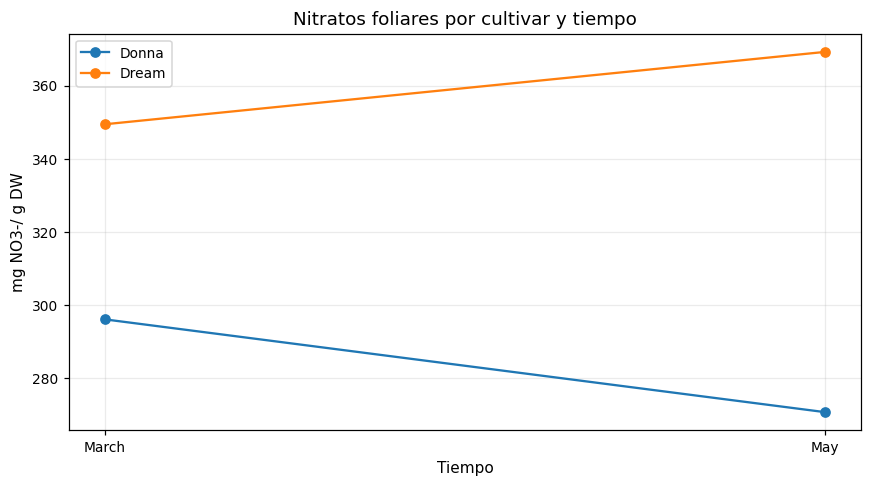

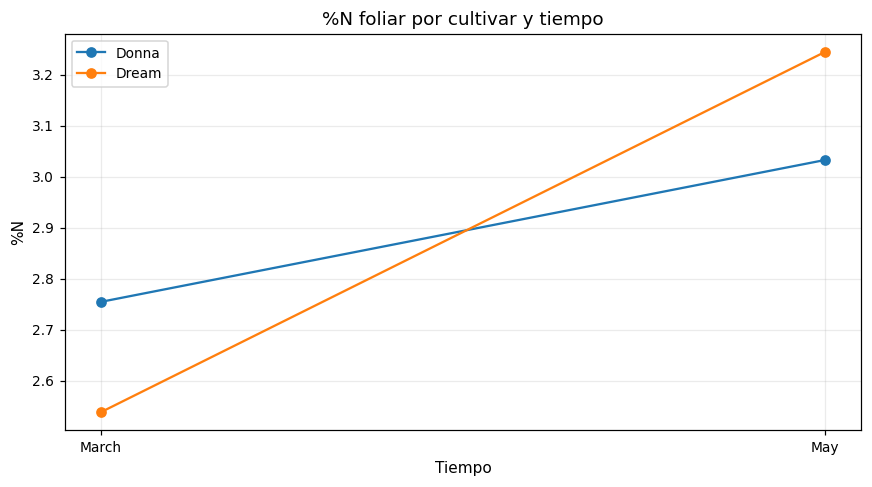

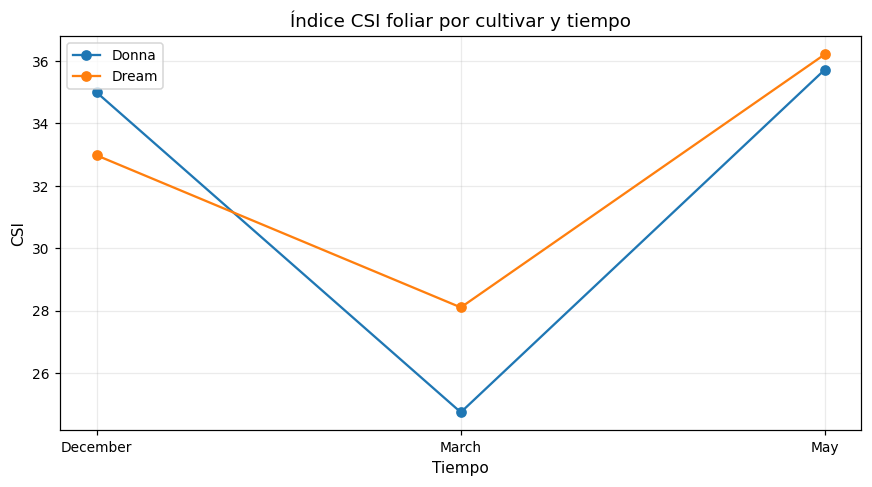

In [ ]:
# Tendencias foliares en variables representativas
iso = leaf_isotopes_raw.copy()
iso['Cultivar'] = standardize_cultivar(iso['Cv'])
iso['Time_std'] = iso['Date'].astype(str).str.extract('(March|May)', expand=False)

nitr = leaf_nitrates_raw.copy()
nitr['Cultivar'] = standardize_cultivar(nitr['Cv'])
nitr['Time_std'] = nitr['Time'].astype(str).str.strip()

rgb = leaf_rgb_raw.copy()
rgb['Cultivar'] = standardize_cultivar(rgb['Cv'])
rgb['Time_std'] = rgb['Time'].astype(str).str.strip()

def temporal_mean_plot(df, variable, time_col, order, title):
    m = df.groupby([time_col, 'Cultivar'], as_index=False)[variable].mean()
    m[time_col] = pd.Categorical(m[time_col], categories=order, ordered=True)
    m = m.sort_values(time_col)
    plt.figure(figsize=(8, 4.5))
    for cv, d in m.groupby('Cultivar', observed=False):
        plt.plot(d[time_col].astype(str), d[variable], marker='o', label=cv)
    plt.ylabel(variable)
    plt.xlabel('Tiempo')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

# NO3- y %N: marzo-mayo; CSI: diciembre-marzo-mayo.
temporal_mean_plot(nitr, 'mg NO3-/ g DW', 'Time_std', ['March','May'], 'Nitratos foliares por cultivar y tiempo')
temporal_mean_plot(iso, '%N', 'Time_std', ['March','May'], '%N foliar por cultivar y tiempo')
temporal_mean_plot(rgb, 'CSI', 'Time_std', ['December','March','May'], 'Índice CSI foliar por cultivar y tiempo')

## 8. Construcción del dataset maestro

La integración se realiza únicamente después de estandarizar llaves. Se conserva una fila por **Cultivar × Tratamiento × Réplica**. Las mediciones longitudinales de hoja se convierten a formato ancho, creando columnas por momento de medición. Esto evita multiplicar filas y mantiene la independencia de las 32 unidades experimentales.


In [ ]:
# 8.1 Antioxidantes consolidados
ant0 = antiox_raw.copy()
ant = pd.DataFrame({
    'Cultivar': standardize_cultivar(ant0['cultivar']),
    'Treatment': standardize_treatment(ant0['Treatment']),
    'Replicate': standardize_replicate(ant0['Replicate']),
})
ant_measures = [c for c in ant0.columns if c not in ['Sample','cultivar','Treatment','Replicate','New_block']]
for c in ant_measures:
    ant[c] = pd.to_numeric(ant0[c], errors='coerce')

# 8.2 Calidad del fruto: se omiten medidas antioxidantes repetidas, pues ya están en Antiox_data.
fr0 = fruit_raw.copy()
fr = pd.DataFrame({
    'Cultivar': standardize_cultivar(fr0['Cv']),
    'Treatment': standardize_treatment(fr0['Treatment']),
    'Replicate': standardize_replicate(fr0['Repl']),
})
fruit_measures = ['Weight','Hydrat','Firm','Hue','Chroma','BRIX','Acidity','GA','GGA','CSI']
for c in fruit_measures:
    fr['fruit_' + c] = pd.to_numeric(fr0[c], errors='coerce')

# 8.3 Rendimiento agregado
y0 = yield_raw.copy()
yld = pd.DataFrame({
    'Cultivar': standardize_cultivar(y0['Cv']),
    'Treatment': standardize_treatment(y0['Treatment']),
    'Replicate': standardize_replicate(y0['Repl']),
})
for c in ['Com Ton/ha','No com Ton/ha','Nº de plantes','g/planta']:
    yld['yield_' + c] = pd.to_numeric(y0[c], errors='coerce')

# 8.4 Suelo 2023: la llave válida es Tratamiento x Réplica.
s0 = soil_raw.loc[soil_raw['Year'].eq(2023)].copy()
soil = pd.DataFrame({
    'Treatment': s0['Treatment'].astype(str).str.strip().str.upper().map(SOIL_TREATMENT_MAP),
    'Replicate': standardize_replicate(s0['Block']),
})
soil_measures = [c for c in s0.columns if c not in ['Treatment','Year','Block','Plot']]
for c in soil_measures:
    soil['soil_' + c] = pd.to_numeric(s0[c], errors='coerce')

# 8.5 Mediciones foliares longitudinales

def pivot_leaf(df, cv_col, tr_col, rep_col, time_series, measures, prefix):
    x = pd.DataFrame({
        'Cultivar': standardize_cultivar(df[cv_col]),
        'Treatment': standardize_treatment(df[tr_col]),
        'Replicate': standardize_replicate(df[rep_col]),
        'Time': pd.Series(time_series, index=df.index).astype(str).str.strip(),
    })
    for c in measures:
        x[c] = pd.to_numeric(df[c], errors='coerce')
    pv = x.pivot_table(index=['Cultivar','Treatment','Replicate'], columns='Time', values=measures, aggfunc='mean')
    pv.columns = [f'{prefix}_{var}_{time}' for var, time in pv.columns]
    return pv.reset_index()

iso_time = leaf_isotopes_raw['Date'].astype(str).str.extract('(March|May)', expand=False)
leaf_iso = pivot_leaf(leaf_isotopes_raw, 'Cv','Treatment','Replicate', iso_time, ['%N','d13C'], 'leaf_iso')

nut_measures = [c for c in leaf_nutrients_raw.columns if c not in ['Sample','Parcel/Plot','Cv','Treatment','Repl','Time'] and not c.startswith('Unnamed')]
leaf_nut = pivot_leaf(leaf_nutrients_raw, 'Cv','Treatment','Repl', leaf_nutrients_raw['Time'], nut_measures, 'leaf_nut')

leaf_no3 = pivot_leaf(leaf_nitrates_raw, 'Cv','Treatment','Repl', leaf_nitrates_raw['Time'], ['mg NO3-/ g DW','mg NO3-/ 100 mg DW'], 'leaf_no3')
leaf_rgb = pivot_leaf(leaf_rgb_raw, 'Cv','Treatment','Repl', leaf_rgb_raw['Time'], ['GA','GGA','CSI'], 'leaf_rgb')

# Integración final con validación explícita de cardinalidad.
master = ant.merge(fr, on=['Cultivar','Treatment','Replicate'], how='outer', validate='one_to_one')
master = master.merge(yld, on=['Cultivar','Treatment','Replicate'], how='outer', validate='one_to_one')
master = master.merge(soil, on=['Treatment','Replicate'], how='left', validate='many_to_one')
for w in [leaf_iso, leaf_nut, leaf_no3, leaf_rgb]:
    master = master.merge(w, on=['Cultivar','Treatment','Replicate'], how='left', validate='one_to_one')

assert master.shape[0] == 32, 'La integración debe conservar 32 unidades experimentales.'
assert master[['Cultivar','Treatment','Replicate']].duplicated().sum() == 0

print('Forma del dataset maestro:', master.shape)
print('Unidades experimentales únicas:', master[['Cultivar','Treatment','Replicate']].drop_duplicates().shape[0])
print('Variables numéricas:', master.select_dtypes(include=np.number).shape[1])
display(master.head())

Forma del dataset maestro: (32, 103)
Unidades experimentales únicas: 32
Variables numéricas: 100


,Cultivar,Treatment,Replicate,Procyanidin B1,Procyanidin B3,Procyanidin C1,K-glucoside,K-rutinoside,Phloridzin,Nar 7 gluc,Rutin,Quercetin,Quercetin-glucoside,Chlorogenic,Catechin,Epicatechin,Gallic acid,Hydroxybenzoic,Hydroxybenzoic 2,Total polyphenols,P gluc,P rut,Cyan,Tot anth,Vit C,fruit_Weight,fruit_Hydrat,fruit_Firm,fruit_Hue,fruit_Chroma,fruit_BRIX,fruit_Acidity,fruit_GA,fruit_GGA,fruit_CSI,yield_Com Ton/ha,yield_No com Ton/ha,yield_Nº de plantes,yield_g/planta,soil_Densidad ap,soil_C org,soil_N,soil_C:N,soil_Microbial_biomass_C_sinincubar,soil_Microbial_biomass_C_incubado,soil_N_microbiano_sinincubar,soil_N_microbiano_incubado,soil_Respiracion_microb (ug C-CO2/gsuelo·dia),soil_N _mineral _sinincubar,soil_N_mineral_incubado,leaf_iso_%N_March,leaf_iso_%N_May,leaf_iso_d13C_March,leaf_iso_d13C_May,leaf_nut_B_March,leaf_nut_B_May,leaf_nut_Ca_March,leaf_nut_Ca_May,leaf_nut_Cd_March,leaf_nut_Cd_May,leaf_nut_Co_March,leaf_nut_Co_May,leaf_nut_Cr_March,leaf_nut_Cr_May,leaf_nut_Cu_March,leaf_nut_Cu_May,leaf_nut_Fe_March,leaf_nut_Fe_May,leaf_nut_K_March,leaf_nut_K_May,leaf_nut_Mg_March,leaf_nut_Mg_May,leaf_nut_Mn_March,leaf_nut_Mn_May,leaf_nut_Mo_March,leaf_nut_Mo_May,leaf_nut_Na_March,leaf_nut_Na_May,leaf_nut_Ni_March,leaf_nut_Ni_May,leaf_nut_P_March,leaf_nut_P_May,leaf_nut_Pb_March,leaf_nut_Pb_May,leaf_nut_S_March,leaf_nut_S_May,leaf_nut_Si_March,leaf_nut_Si_May,leaf_nut_Zn_March,leaf_nut_Zn_May,leaf_no3_mg NO3-/ 100 mg DW_March,leaf_no3_mg NO3-/ 100 mg DW_May,leaf_no3_mg NO3-/ g DW_March,leaf_no3_mg NO3-/ g DW_May,leaf_rgb_CSI_December,leaf_rgb_CSI_March,leaf_rgb_CSI_May,leaf_rgb_GA_December,leaf_rgb_GA_March,leaf_rgb_GA_May,leaf_rgb_GGA_December,leaf_rgb_GGA_March,leaf_rgb_GGA_May
0,Donna,T1,R1,10.464691,39.277,0.503,1.230,0.0,1.210,0.265,0.0,9.410,0.372,0.466,13.777,0.669,0.117,346.625,0.671,425.056691,50.149877,0.0,2.496868,52.646745,1.387,11.330,85.314685,1.88,27.386915,48.326401,8.8,0.8320,0.467367,0.308508,34.151106,8.242667,1.064889,18,515.166667,1.320629,2.895052,0.3,9.650172,98.59643,58.49244,21.42322,6.61596,23.63184,48.10417,275.09079,2.599251,2.911282,-27.803433,-27.391670,0.048340,0.047190,8.844680,18.465275,0.000154,0.010110,0.152572,0.232803,0.258550,0.460712,5.865385,8.803489,0.444227,0.703158,13.174304,17.333868,3.576670,4.409995,0.117722,0.079447,0.683205,0.057183,0.239479,0.070397,0.860114,0.655172,4.229935,2.370832,31.058969,2.162831,1.549705,1.802118,0.039702,0.048434,0.039673,0.024092,32.399510,47.036765,334.567429,462.914720,30.744133,25.227758,34.151106,0.564938,0.429641,0.467367,0.395403,0.322145,0.308508
1,Donna,T1,R2,13.149961,42.324,0.568,1.720,0.0,1.829,0.366,0.0,26.274,0.844,0.430,17.124,0.984,0.116,1018.327,0.556,1124.611961,66.898737,0.0,3.181186,70.079922,1.534,10.206,87.058824,1.26,32.614015,44.306171,10.2,0.8448,0.601496,0.373225,38.072643,7.809778,0.884444,19,462.421053,1.379313,2.382643,0.2,11.913214,180.37339,93.36736,31.89763,3.20643,22.95412,35.74306,194.12235,2.619458,3.090566,-28.337200,-27.141562,0.045732,0.057067,8.956760,17.383456,0.003461,0.007922,0.177491,0.137157,0.685601,0.191094,6.909637,7.828039,0.511108,0.399805,14.621327,18.082910,3.730152,4.263730,0.175916,0.116174,0.215073,0.166743,0.060116,0.041074,0.515124,1.001304,4.363810,2.524363,1.457615,1.269503,1.714976,1.760405,0.084488,0.028273,0.030112,0.020369,30.781863,27.100490,318.356218,262.144421,35.942528,24.664145,38.072643,0.442920,0.420427,0.601496,0.283858,0.317011,0.373225
2,Donna,T1,R3,27.839555,106.433,1.955,3.576,0.0,3.354,0.425,0.0,157.121,2.584,0.429,32.103,1.559,0.123,557.678,0.520,895.699555,58.050712,0.0,3.276940,61.327652,2.261,9.242,86.956522,1.20,25.907189,43.234988,10.0,0.8320,0.459232,0.320981,30.152888,7.267556,0.688889,19,430.315789,1.251084,2.958259,0.3,9.860863,10.44186,3.14375,0.00000,0.00000,20.74416,14.84028,45.90359,2.602377,2.894935,-28.281282,-27.196464,0.046673,0.047380,8.968414,18.254859,0.024343,0.617643,0.088255,0.164794,-0.028646,0.286937,5.515939,8.117793,0.285547,0.509235,14.038200,18.8798

In [ ]:
# Verificación de variables repetidas entre Antiox_data y Sampling/all_data.
# Se espera que P gluc, P rut, Cyan y Tot anth sean prácticamente idénticas;
# Vit C tiene pequeñas diferencias de redondeo.
checks = []
for c in ['Vit C','P gluc','P rut','Cyan','Tot anth']:
    a = ant[['Cultivar','Treatment','Replicate',c]]
    b0 = fruit_raw.copy()
    b = pd.DataFrame({
        'Cultivar': standardize_cultivar(b0['Cv']),
        'Treatment': standardize_treatment(b0['Treatment']),
        'Replicate': standardize_replicate(b0['Repl']),
        c: pd.to_numeric(b0[c], errors='coerce')
    })
    chk = a.merge(b, on=['Cultivar','Treatment','Replicate'], suffixes=('_antiox','_sampling'))
    diff = (chk[c+'_antiox'] - chk[c+'_sampling']).abs()
    checks.append({'Variable': c, 'Diferencia máxima absoluta': diff.max(), 'Coincide a 1e-6': bool((diff.fillna(0) <= 1e-6).all())})
display(pd.DataFrame(checks))

,Variable,Diferencia máxima absoluta,Coincide a 1e-6
0,Vit C,4.952614e-04,False
1,P gluc,4.670687e-08,True
2,P rut,4.671538e-09,True
3,Cyan,4.595751e-09,True
4,Tot anth,4.941450e-08,True


## 9. Matriz de correlación multivariante

Se utiliza **Spearman** porque varias variables presentan fuerte sesgo y el tamaño de muestra es pequeño. Se calcula la matriz completa de todas las variables numéricas del dataset maestro y se guarda en CSV para consulta detallada. Además se listan los pares con correlación absoluta alta para detectar redundancias.


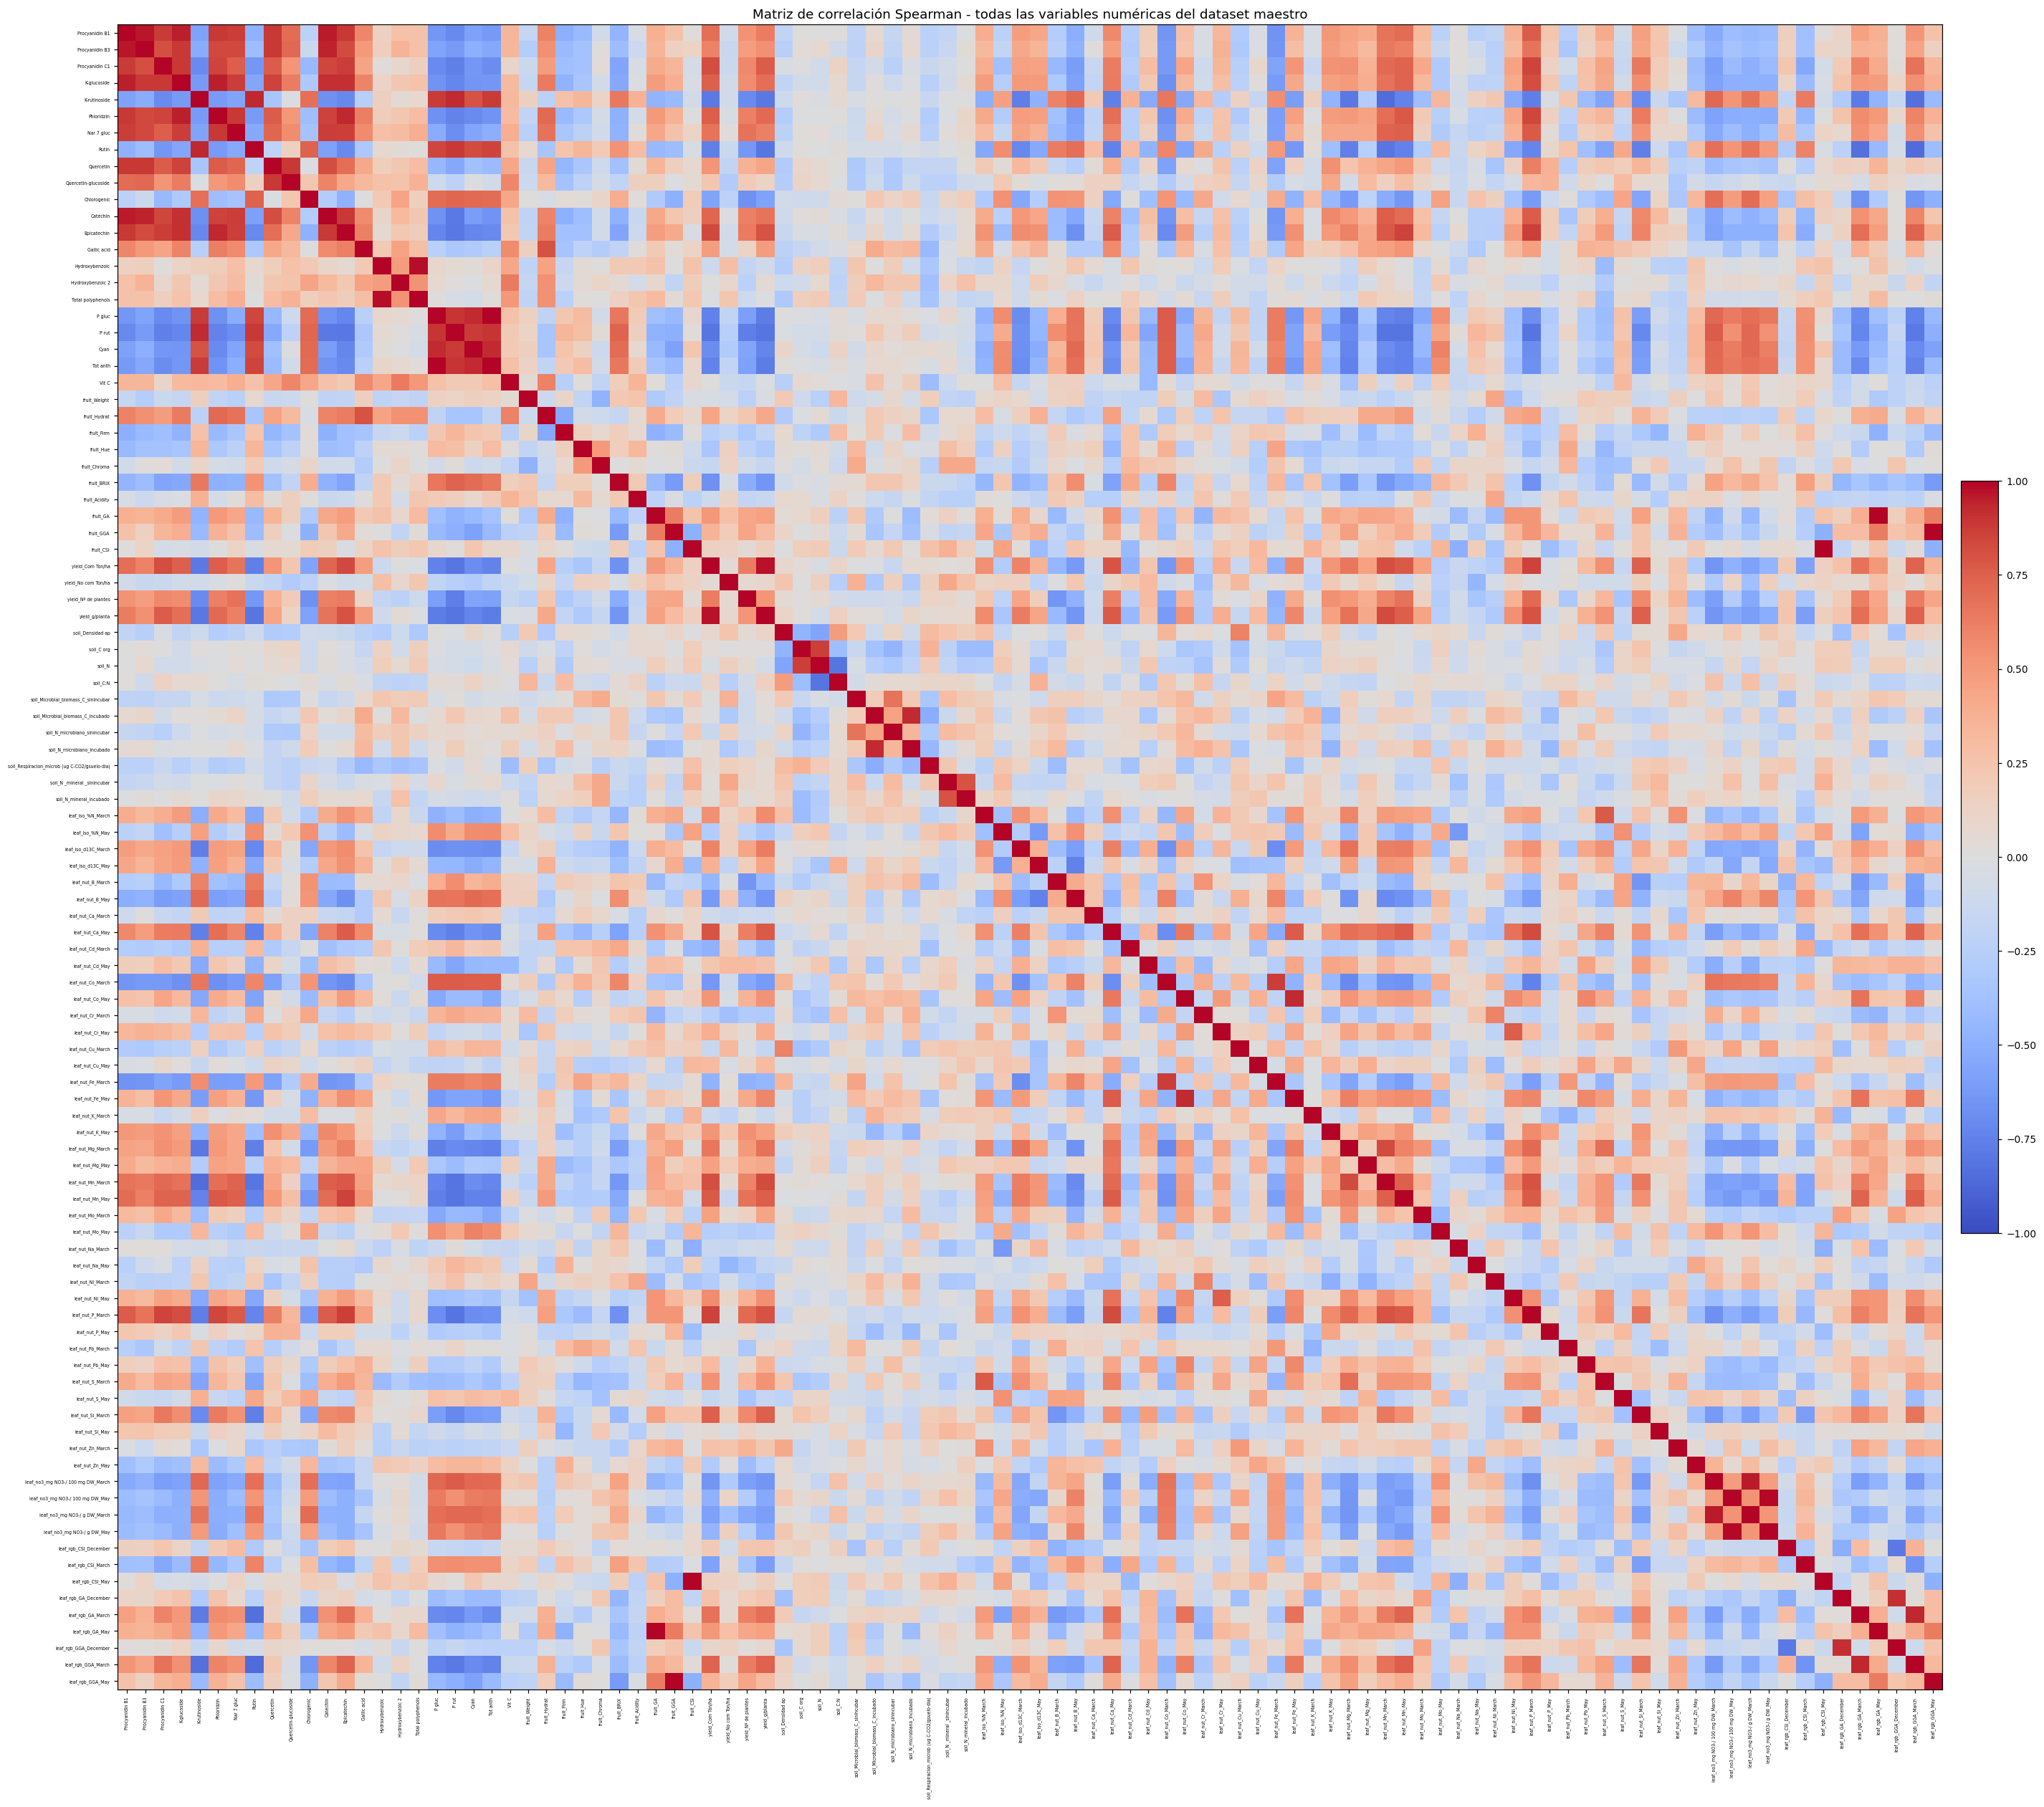

Pares con |rho| >= 0.90: 24


,Variable 1,Variable 2,Spearman rho,|rho|
16,fruit_CSI,leaf_rgb_CSI_May,1.000,1.000
15,fruit_GGA,leaf_rgb_GGA_May,1.000,1.000
14,fruit_GA,leaf_rgb_GA_May,1.000,1.000
12,P gluc,Tot anth,0.999,0.999
21,leaf_no3_mg NO3-/ 100 mg DW_May,leaf_no3_mg NO3-/ g DW_May,0.987,0.987
10,Hydroxybenzoic,Total polyphenols,0.980,0.980
17,yield_Com Ton/ha,yield_g/planta,0.976,0.976
0,Procyanidin B1,Procyanidin B3,0.963,0.963
2,Procyanidin B1,Catechin,0.958,0.958
20,leaf_no3_mg NO3-/ 100 mg DW_March,leaf_no3_mg NO3-/ g DW_March,0.957,0.957


In [ ]:
num_master = master.select_dtypes(include=np.number).copy()
corr_spearman = num_master.corr(method='spearman')
corr_spearman.to_csv(OUTPUT_DIR / 'correlation_master_spearman.csv')

# Heatmap completo. Con ~100 variables las etiquetas son densas, pero la imagen puede ampliarse en Jupyter.
fig, ax = plt.subplots(figsize=(26, 23))
im = ax.imshow(corr_spearman.values, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
ax.set_xticks(range(len(corr_spearman.columns)))
ax.set_yticks(range(len(corr_spearman.columns)))
ax.set_xticklabels(corr_spearman.columns, rotation=90, fontsize=4)
ax.set_yticklabels(corr_spearman.columns, fontsize=4)
ax.set_title('Matriz de correlación Spearman - todas las variables numéricas del dataset maestro')
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_master_full.png', dpi=160, bbox_inches='tight')
plt.show()

# Pares de alta correlación
pairs = []
cols = list(corr_spearman.columns)
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        rho = corr_spearman.iloc[i, j]
        if pd.notna(rho) and abs(rho) >= 0.90:
            pairs.append({'Variable 1': cols[i], 'Variable 2': cols[j], 'Spearman rho': rho, '|rho|': abs(rho)})
high_corr_df = pd.DataFrame(pairs).sort_values('|rho|', ascending=False)
print('Pares con |rho| >= 0.90:', len(high_corr_df))
display(high_corr_df.head(40).round(3))

In [ ]:
# Correlación de todas las variables con resultados analíticos de interés.
outcomes = [c for c in ['Total polyphenols','Tot anth','Vit C','yield_g/planta','yield_Com Ton/ha'] if c in corr_spearman.columns]
for outcome in outcomes:
    s = corr_spearman[outcome].drop(labels=[outcome]).dropna().sort_values(key=lambda x: x.abs(), ascending=False).head(15)
    display(Markdown(f'### Variables más correlacionadas con `{outcome}`'))
    display(s.rename('Spearman rho').to_frame().round(3))

### Variables más correlacionadas con `Total polyphenols`

,Spearman rho
Hydroxybenzoic,0.980
fruit_Hydrat,0.534
Hydroxybenzoic 2,0.525
Vit C,0.502
leaf_nut_S_March,-0.389
Nar 7 gluc,0.384
Quercetin-glucoside,0.363
soil_Respiracion_microb (ug C-CO2/gsuelo·dia),-0.345
leaf_rgb_GA_May,0.312
fruit_GA,0.312


### Variables más correlacionadas con `Tot anth`

,Spearman rho
P gluc,0.999
Cyan,0.929
P rut,0.896
K-rutinoside,0.876
Rutin,0.845
yield_g/planta,-0.769
leaf_nut_Co_March,0.756
leaf_nut_Mn_May,-0.748
leaf_nut_Mg_March,-0.742
leaf_rgb_GGA_March,-0.738


### Variables más correlacionadas con `Vit C`

,Spearman rho
Hydroxybenzoic 2,0.636
fruit_Hydrat,0.602
Quercetin-glucoside,0.581
Gallic acid,0.567
Total polyphenols,0.502
leaf_nut_Cd_May,-0.428
Chlorogenic,0.428
Hydroxybenzoic,0.427
Quercetin,0.423
soil_Respiracion_microb (ug C-CO2/gsuelo·dia),-0.401


### Variables más correlacionadas con `yield_g/planta`

,Spearman rho
yield_Com Ton/ha,0.976
leaf_nut_Mn_March,0.823
P rut,-0.808
leaf_nut_P_March,0.802
Rutin,-0.801
Epicatechin,0.798
K-rutinoside,-0.795
leaf_nut_Ca_May,0.773
P gluc,-0.770
Tot anth,-0.769


### Variables más correlacionadas con `yield_Com Ton/ha`

,Spearman rho
yield_g/planta,0.976
leaf_nut_P_March,0.853
Epicatechin,0.828
Procyanidin C1,0.815
leaf_nut_Mn_March,0.805
P rut,-0.803
leaf_nut_Ca_May,0.794
K-rutinoside,-0.783
leaf_nut_Mn_May,0.769
Rutin,-0.757


## 10. Preprocesamiento justificado

### Estrategias aplicadas
- **Nombres/categorías:** se homologan `DO/Dona/Donna` a `Donna`, `DR/Dream` a `Dream` y se eliminan espacios en tratamientos/réplicas.
- **Fechas:** se convierten textos catalanes de cosecha a fechas de 2023.
- **Valores faltantes:** se conservan en los datos descriptivos. Para PCA y selección no supervisada se imputan únicamente en una copia de modelado con mediana.
- **Atípicos:** no se eliminan automáticamente; se identifican por IQR y se reduce su influencia con Yeo-Johnson + RobustScaler.
- **Alta cardinalidad:** identificadores como `Sample`, `Name`, `Parcel` o IDs de laboratorio no se incorporan como predictores.
- **Redundancia:** se eliminan duplicados exactos y se proponen descartes cuando |Spearman| > 0.90.
- **Sesgo:** variables con |skewness| > 1 se transforman con Yeo-Johnson en la matriz destinada al análisis multivariante.


In [ ]:
# Faltantes reales del dataset maestro
master_missing = master.isna().sum()
master_missing = master_missing[master_missing > 0].sort_values(ascending=False)
print('Celdas faltantes en master:', int(master.isna().sum().sum()))
display(master_missing.rename('Faltantes').to_frame())

# Filas afectadas por antocianinas faltantes
anth_cols = [c for c in ['P gluc','P rut','Cyan','Tot anth'] if c in master.columns]
if anth_cols:
    affected = master.loc[master[anth_cols].isna().any(axis=1), ['Cultivar','Treatment','Replicate'] + anth_cols]
    display(Markdown('### Unidades afectadas por faltantes en antocianinas'))
    display(affected)

Celdas faltantes en master: 14


,Faltantes
P gluc,3
P rut,3
Cyan,3
Tot anth,3
fruit_Hue,1
fruit_Chroma,1


### Unidades afectadas por faltantes en antocianinas

,Cultivar,Treatment,Replicate,P gluc,P rut,Cyan,Tot anth
16,Dream,T1,R1,NaN,NaN,NaN,NaN
21,Dream,T2,R2,NaN,NaN,NaN,NaN
24,Dream,T3,R1,NaN,NaN,NaN,NaN


In [ ]:
# Duplicados numéricos exactos / casi exactos

def exact_duplicate_pairs(df, atol=1e-12):
    numeric = df.select_dtypes(include=np.number)
    cols = list(numeric.columns)
    found = []
    for i in range(len(cols)):
        a = numeric[cols[i]].to_numpy(dtype=float)
        for j in range(i+1, len(cols)):
            b = numeric[cols[j]].to_numpy(dtype=float)
            mask = ~(np.isnan(a) | np.isnan(b))
            if mask.sum() == 0:
                continue
            # Duplicado si coinciden todos los valores disponibles y el patrón de NaN es el mismo.
            same_nan = np.array_equal(np.isnan(a), np.isnan(b))
            if same_nan and np.allclose(a[mask], b[mask], atol=atol, rtol=0):
                found.append((cols[i], cols[j]))
    return found

exact_pairs = exact_duplicate_pairs(master)
print('Pares numéricos exactamente duplicados:', len(exact_pairs))
for p in exact_pairs:
    print('  ', p)

Pares numéricos exactamente duplicados: 3
   ('fruit_GA', 'leaf_rgb_GA_May')
   ('fruit_GGA', 'leaf_rgb_GGA_May')
   ('fruit_CSI', 'leaf_rgb_CSI_May')


## 11. Selección de características y reducción de dimensionalidad

El dataset integrado tiene **muchas más variables que observaciones**, por lo que alimentar directamente un modelo con todas las columnas produciría alto riesgo de sobreajuste. La selección se realiza en tres niveles:

1. eliminar duplicados exactos;
2. reducir variables altamente correlacionadas, protegiendo resultados clave;
3. evaluar cuántos componentes principales son necesarios para resumir la variabilidad.

> Para un modelo supervisado futuro, cualquier selección de variables deberá ejecutarse **dentro de cada partición de validación cruzada** para evitar fuga de información.


In [ ]:
# Matriz numérica para selección. No se usan identificadores/categorías como variables continuas.
X_raw = master.select_dtypes(include=np.number).copy()

# 1) Eliminar segunda columna de cada par exacto, salvo que sea un outcome protegido.
PROTECTED = {'Total polyphenols','Tot anth','Vit C','yield_g/planta','yield_Com Ton/ha'}
exact_drop = []
for a, b in exact_pairs:
    if b not in PROTECTED:
        exact_drop.append(b)
    elif a not in PROTECTED:
        exact_drop.append(a)
exact_drop = sorted(set(exact_drop))
X1 = X_raw.drop(columns=exact_drop, errors='ignore')

# 2) Imputación solo para la matriz multivariante.
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X1), columns=X1.columns, index=X1.index)

# 3) Candidatos por alta correlación. Se conserva el primer miembro salvo outcomes protegidos.
corr_abs = X_imp.corr(method='spearman').abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
correlated_drop = []
for col in upper.columns:
    partners = list(upper.index[upper[col] > 0.90])
    if not partners:
        continue
    if col in PROTECTED:
        # Si col es outcome, se intenta retirar primero un predictor redundante.
        removable = [p for p in partners if p not in PROTECTED]
        correlated_drop.extend(removable)
    else:
        correlated_drop.append(col)
correlated_drop = sorted(set(correlated_drop) - PROTECTED)
X2 = X_imp.drop(columns=correlated_drop, errors='ignore')

print('Variables numéricas iniciales:', X_raw.shape[1])
print('Duplicados exactos retirados:', len(exact_drop))
print('Variables sugeridas para retiro por |rho| > 0.90:', len(correlated_drop))
print('Variables restantes antes de PCA:', X2.shape[1])

Variables numéricas iniciales: 100
Duplicados exactos retirados: 3
Variables sugeridas para retiro por |rho| > 0.90: 15
Variables restantes antes de PCA: 82


In [ ]:
# Transformación de sesgo y escalamiento robusto
skew = X2.skew().abs()
skewed_cols = list(skew[skew > 1].index)
X_trans = X2.copy()

if skewed_cols:
    pt = PowerTransformer(method='yeo-johnson', standardize=False)
    X_trans[skewed_cols] = pt.fit_transform(X_trans[skewed_cols])

scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_trans), columns=X_trans.columns, index=X_trans.index)

print('Variables transformadas con Yeo-Johnson por |skewness| > 1:', len(skewed_cols))

Variables transformadas con Yeo-Johnson por |skewness| > 1: 27


,Varianza acumulada objetivo,Componentes requeridos
0,70%,9
1,80%,12
2,90%,17
3,95%,21


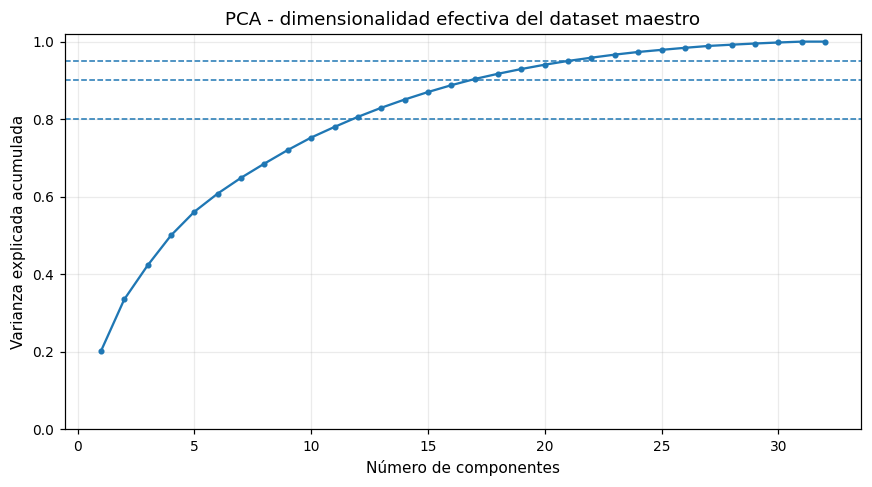

In [ ]:
# PCA exploratorio para cuantificar la dimensionalidad efectiva.
# PCA requiere escala comparable entre variables; por ello usa la matriz preprocesada.
pca = PCA(random_state=RANDOM_STATE)
Z = pca.fit_transform(X_scaled)
cum = np.cumsum(pca.explained_variance_ratio_)

thresholds = {}
for threshold in [0.70, 0.80, 0.90, 0.95]:
    thresholds[threshold] = int(np.searchsorted(cum, threshold) + 1)

pca_summary = pd.DataFrame({
    'Varianza acumulada objetivo': [f'{int(k*100)}%' for k in thresholds],
    'Componentes requeridos': list(thresholds.values())
})
display(pca_summary)

plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(cum)+1), cum, marker='o', markersize=3)
for level in [0.80, 0.90, 0.95]:
    plt.axhline(level, linestyle='--', linewidth=1)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - dimensionalidad efectiva del dataset maestro')
plt.ylim(0, 1.02)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
# Variables con mayor carga absoluta en PC1 y PC2 (orientativo, no causal).
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_scaled.columns,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)
for pc in ['PC1','PC2']:
    top = loadings[pc].sort_values(key=lambda s: s.abs(), ascending=False).head(15)
    display(Markdown(f'### Mayores cargas absolutas en {pc}'))
    display(top.rename('Loading').to_frame().round(3))

### Mayores cargas absolutas en PC1

,Loading
fruit_GA,0.251
yield_Nº de plantes,0.238
leaf_iso_%N_March,0.181
leaf_nut_Mg_March,0.179
fruit_Hydrat,0.178
leaf_nut_P_March,0.174
leaf_no3_mg NO3-/ 100 mg DW_March,-0.173
Procyanidin B1,0.167
fruit_BRIX,-0.166
leaf_nut_Mn_May,0.161


### Mayores cargas absolutas en PC2

,Loading
soil_C org,0.838
leaf_nut_Pb_March,0.185
soil_N_microbiano_sinincubar,-0.174
soil_Microbial_biomass_C_incubado,-0.135
leaf_iso_%N_March,-0.129
leaf_nut_K_March,-0.120
soil_N,0.118
leaf_rgb_GA_December,0.114
soil_N_mineral_incubado,-0.108
leaf_nut_Cd_May,0.105


## 12. Conclusiones del EDA

1. **La integración correcta no es una concatenación de archivos.** La unidad analítica defendible es Cultivar × Tratamiento × Réplica (32 unidades). Los ensayos de polifenoles, antocianinas y vitamina C incluyen réplicas técnicas y deben agregarse antes del análisis entre tratamientos.
2. **El dataset integrado es de alta dimensionalidad.** Hay alrededor de 100 variables numéricas para solo 32 unidades experimentales. Esto hace obligatoria la reducción de variables antes de construir modelos complejos.
3. **Los faltantes están concentrados.** En el maestro, las ausencias principales corresponden a antocianinas en tres unidades de `Dream` y a una observación sin Hue/Chroma. No se recomienda rellenarlas en el EDA descriptivo; la imputación por mediana se usa únicamente en la copia multivariante.
4. **Existen variables redundantes.** Parte de los indicadores RGB de fruto coincide con mediciones de mayo del archivo foliar, y varias variables químicas presentan correlaciones >0.90. También `g/planta` y `Com Ton/ha` contienen información de rendimiento muy similar.
5. **Las distribuciones no son homogéneas.** Diversas variables químicas y micronutrientes presentan sesgo fuerte y observaciones extremas. Se recomienda Yeo-Johnson y escalamiento robusto, evitando borrar observaciones experimentales automáticamente.
6. **Se observan señales claras por cultivar.** En el EDA actual, `Dream` presenta niveles de antocianinas totales considerablemente superiores, mientras `Donna` muestra mayor rendimiento comercial por planta. La vitamina C es mucho más similar entre cultivares. Estas diferencias deben validarse inferencialmente antes de convertirlas en conclusiones científicas.
7. **Hay estructura temporal relevante.** La producción comercial sigue perfiles distintos entre cultivares; además, nitratos, %N y RGB foliar cambian entre momentos de medición. Por ello, el tiempo no debe descartarse ni mezclarse sin control.
8. **No aplica el análisis de desbalance de clases**, porque en este avance no se ha definido una variable objetivo de clasificación. Tampoco existen imágenes crudas para normalizar: solo se cuenta con variables RGB derivadas.
9. **PCA es útil como diagnóstico de dimensionalidad**, pero no reemplaza la selección científica. La combinación recomendada es: depuración por dominio + eliminación de redundancias + PCA/regularización según el modelo final.

### Siguiente paso recomendado
Definir de forma explícita el criterio de optimización del proyecto (por ejemplo, una función que combine perfil antioxidante, calidad y rendimiento). Esa decisión permitirá pasar del EDA a un esquema de apoyo a decisiones sin forzar una variable objetivo artificial.


In [ ]:
# Evidencia cuantitativa que sustenta las conclusiones anteriores.
summary_rows = []
for outcome in ['Total polyphenols','Tot anth','Vit C']:
    g = master.groupby('Cultivar')[outcome].agg(['mean','median','std']).round(3)
    for cv_name, row in g.iterrows():
        summary_rows.append({'Resultado': outcome, 'Cultivar': cv_name, **row.to_dict()})

g = master.groupby('Cultivar')['yield_g/planta'].agg(['mean','median','std']).round(3)
for cv_name, row in g.iterrows():
    summary_rows.append({'Resultado': 'yield_g/planta', 'Cultivar': cv_name, **row.to_dict()})

display(pd.DataFrame(summary_rows))

print('Dimensión del master:', master.shape)
print('Faltantes en master:', int(master.isna().sum().sum()))
print('Pares con |Spearman| >= 0.90:', len(high_corr_df))
print('Componentes PCA para 80%:', thresholds[0.80])
print('Componentes PCA para 90%:', thresholds[0.90])

,Resultado,Cultivar,mean,median,std
0,Total polyphenols,Donna,1657.675,1151.472,1384.662
1,Total polyphenols,Dream,1263.938,1168.470,547.413
2,Tot anth,Donna,54.802,55.355,13.561
3,Tot anth,Dream,399.215,411.463,82.601
4,Vit C,Donna,2.588,2.341,1.134
5,Vit C,Dream,2.578,2.584,0.527
6,yield_g/planta,Donna,474.645,464.817,59.305
7,yield_g/planta,Dream,206.332,202.455,47.821


Dimensión del master: (32, 103)
Faltantes en master: 14
Pares con |Spearman| >= 0.90: 24
Componentes PCA para 80%: 12
Componentes PCA para 90%: 17


## 13. Exportación de productos reproducibles

Se guardan el dataset maestro sin imputar, la matriz de correlación completa y el inventario de fuentes. Estos productos son auxiliares para trazabilidad; el notebook sigue siendo el entregable principal.


In [ ]:
master.to_csv(OUTPUT_DIR / 'master_dataset_eda.csv', index=False)
inventory_df.to_csv(OUTPUT_DIR / 'inventario_fuentes.csv', index=False)
high_corr_df.to_csv(OUTPUT_DIR / 'high_correlation_pairs.csv', index=False)

print('Archivos generados en: [TEC_PROYECTO] Antioxidantes en fresas - General\03. Avance 1 - Análisis exploratorio\outputs')
for p in sorted(OUTPUT_DIR.iterdir()):
    print(' -', p.name)

Archivos generados en: [TEC_PROYECTO] Antioxidantes en fresas - General. Avance 1 - Análisis exploratorio\outputs
 - correlation_master_full.png
 - correlation_master_spearman.csv
 - high_correlation_pairs.csv
 - inventario_fuentes.csv
 - master_dataset_eda.csv


## Referencias

Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., & Plöd, M. (2023). *CRISP-ML(Q): The ML lifecycle process*. MLOps. INNOQ. https://ml-ops.org/content/crisp-ml

Kumar Mukhiya, S., & Ahmed, U. (2020). *Hands-On Exploratory Data Analysis with Python*. Packt Publishing.

**Uso de IA generativa.** ChatGPT (OpenAI) se utilizó como apoyo para estructurar el notebook, documentar el código y perfilar la narrativa del análisis. Las decisiones de integración, interpretación estadística y conclusiones deben ser validadas por el equipo con base en el diseño experimental y el conocimiento científico del proyecto.
